# 99 — Results for Thesis

Aggregates all saved metrics into clean tables and figures ready for the thesis.

**No models are loaded or training is done here — everything is read from JSON files.**

## Prerequisites
Run these notebooks in order to generate all result files:

| Notebook | What it trains |
|----------|----------------|
| `10_train_text.ipynb` | BERT, DistilBERT |
| `11_train_audio.ipynb` | wav2vec2-base, DistilHuBERT |
| `12_train_face.ipynb` | ViT-B/16, MobileNetV3-Small |
| `20_eval_text.ipynb` | Text eval metrics |
| `21_eval_audio.ipynb` | Audio eval metrics |
| `22_eval_face.ipynb` | Face eval metrics |
| `30_late_fusion.ipynb` (COMBO="heavy") | Late fusion — heavy |
| `30_late_fusion.ipynb` (COMBO="light") | Late fusion — light |
| `31_intermediate_fusion.ipynb` (COMBO="heavy") | Intermediate fusion — heavy |
| `31_intermediate_fusion.ipynb` (COMBO="light") | Intermediate fusion — light |

Missing results are skipped gracefully.

In [132]:
import os, sys, json, warnings

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

from src.config import (
    EXP_ROOT, EXP_ROOT_AUDIO, EXP_ROOT_FACE, VERSION,
    MODELS_TO_RUN, AUDIO_MODELS_TO_RUN, FACE_MODELS_TO_RUN,
)
from src.training.utils import slugify

# ── Experiment directories ────────────────────────────────────────────────────
LATE_FUSION_ROOT  = f'../experiments/fusion/late/{VERSION}'
INTER_FUSION_ROOT = f'../experiments/fusion/intermediate/{VERSION}'
GATED_FUSION_ROOT = f'../experiments/fusion/gated/{VERSION}'

COMBOS = ['heavy', 'light']
COMBO_LABELS = {
    'heavy': 'Heavy (BERT + wav2vec2 + ViT)',
    'light': 'Light (DistilBERT + DistilHuBERT + MobileNet)',
}

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

def safe_load_json(path, default=None):
    if os.path.exists(path):
        return load_json(path)
    return default

print(f'Experiment root : {os.path.abspath(EXP_ROOT)}')
print(f'Late fusion dir : {os.path.abspath(LATE_FUSION_ROOT)}')
print(f'Interm. fusion  : {os.path.abspath(INTER_FUSION_ROOT)}')

Experiment root : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\text_unimodal
Late fusion dir : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\fusion\late\v1
Interm. fusion  : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\fusion\intermediate\v1


---
## 1 — Unimodal Results

In [133]:
# ── Load unimodal metrics ─────────────────────────────────────────────────────
# Text and Audio share the same JSON structure:
#   train_metrics.json → { params: {total_params, trainable_params},
#                          best_epoch, best_dev_macro_f1, train_time_s,
#                          power: {avg_power_w, energy_kwh} }
#   eval_metrics.json  → { accuracy, macro_f1, weighted_f1,
#                          inference_ms_per_sample_bs1 }
#
# Face has a different (flat) structure:
#   train_metrics.json → { model_name, best_dev_macro_f1,
#                          total_params, trainable_params,
#                          training_time_s, avg_gpu_power_w, energy_kwh }
#   eval_metrics.json  → { model_name, accuracy, macro_f1, weighted_f1,
#                          num_test_utterances, num_test_frames,
#                          inference_ms_per_sample_bs1 }

records = []

# ── Text models ───────────────────────────────────────────────────────────────
for model_name in MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Text',
        'model':            model_name,
        'total_params_M':   round(tm['params']['total_params'] / 1e6, 3),
        'trainable_M':      round(tm['params']['trainable_params'] / 1e6, 3),
        'best_epoch':       tm.get('best_epoch', None),
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('train_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('power', {}).get('avg_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('power', {}).get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

# ── Audio models ──────────────────────────────────────────────────────────────
for model_name in AUDIO_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_AUDIO, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Audio',
        'model':            model_name,
        'total_params_M':   round(tm['params']['total_params'] / 1e6, 3),
        'trainable_M':      round(tm['params']['trainable_params'] / 1e6, 3),
        'best_epoch':       tm.get('best_epoch', None),
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('train_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('power', {}).get('avg_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('power', {}).get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

# ── Face models ───────────────────────────────────────────────────────────────
# Face train_metrics has FLAT structure (no 'params' nesting, different key names)
for model_name in FACE_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_FACE, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Face',
        'model':            model_name,
        'total_params_M':   round(tm.get('total_params', float('nan')) / 1e6, 3),
        'trainable_M':      round(tm.get('trainable_params', float('nan')) / 1e6, 3),
        'best_epoch':       None,  # face training logs don't record best_epoch
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('training_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('avg_gpu_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

unimodal_df = pd.DataFrame(records)
print(f'Loaded {len(unimodal_df)} unimodal model records')
unimodal_df

Loaded 6 unimodal model records


,modality,model,total_params_M,trainable_M,best_epoch,best_dev_macro_f1,train_time_min,avg_power_w,energy_kwh,test_accuracy,test_macro_f1,test_weighted_f1,infer_ms_bs1
0,Text,bert-base-uncased,109.488,109.488,9.0,0.4650,11.91,110.69,0.0207,0.6165,0.4428,0.6085,11.5531
1,Text,distilbert-base-uncased,66.959,66.959,12.0,0.4393,8.44,108.03,0.0143,0.5877,0.4123,0.5885,5.8248
2,Audio,facebook/wav2vec2-base,94.570,94.570,14.0,0.2767,132.55,146.13,0.3055,0.4268,0.2507,0.4273,19.2474
3,Audio,ntu-spml/distilhubert,23.691,23.691,13.0,0.2298,50.14,149.15,0.1182,0.4299,0.2226,0.4096,6.3300
4,Face,vit_b_16,85.804,85.804,NaN,0.2543,138.51,148.60,0.3389,0.3426,0.2389,0.3558,15.0130
5,Face,mobilenet_v3_small,1.525,1.525,NaN,0.2107,42.76,42.42,0.0299,0.2378,0.1826,0.2176,0.4780


### 1a — Performance table (test set)

In [134]:
perf = unimodal_df[['modality', 'model', 'test_accuracy', 'test_macro_f1', 'test_weighted_f1', 'infer_ms_bs1']].copy()
perf.columns = ['Modality', 'Model', 'Accuracy', 'Macro F1', 'Weighted F1', 'Infer ms (bs=1)']
perf = perf.set_index(['Modality', 'Model']).round(4)
perf

Accuracy  Macro F1  Weighted F1  \
Modality Model                                                      
Text     bert-base-uncased          0.6165    0.4428       0.6085   
         distilbert-base-uncased    0.5877    0.4123       0.5885   
Audio    facebook/wav2vec2-base     0.4268    0.2507       0.4273   
         ntu-spml/distilhubert      0.4299    0.2226       0.4096   
Face     vit_b_16                   0.3426    0.2389       0.3558   
         mobilenet_v3_small         0.2378    0.1826       0.2176   

                                  Infer ms (bs=1)  
Modality Model                                     
Text     bert-base-uncased                11.5531  
         distilbert-base-uncased           5.8248  
Audio    facebook/wav2vec2-base           19.2474  
         ntu-spml/distilhubert             6.3300  
Face     vit_b_16                         15.0130  
         mobilenet_v3_small                0.4780

### 1b — Efficiency table

In [135]:
eff = unimodal_df[['modality', 'model', 'total_params_M', 'train_time_min', 'avg_power_w', 'energy_kwh']].copy()
eff.columns = ['Modality', 'Model', 'Params (M)', 'Train time (min)', 'Avg power (W)', 'Energy (kWh)']
eff = eff.set_index(['Modality', 'Model']).round(3)
eff

Params (M)  Train time (min)  Avg power (W)  \
Modality Model                                                                  
Text     bert-base-uncased           109.488             11.91         110.69   
         distilbert-base-uncased      66.959              8.44         108.03   
Audio    facebook/wav2vec2-base       94.570            132.55         146.13   
         ntu-spml/distilhubert        23.691             50.14         149.15   
Face     vit_b_16                     85.804            138.51         148.60   
         mobilenet_v3_small            1.525             42.76          42.42   

                                  Energy (kWh)  
Modality Model                                  
Text     bert-base-uncased               0.021  
         distilbert-base-uncased         0.014  
Audio    facebook/wav2vec2-base          0.306  
         ntu-spml/distilhubert           0.118  
Face     vit_b_16                        0.339  
         mobilenet_v3_small              0.030

### 1c — Macro F1 bar chart (all unimodal models)

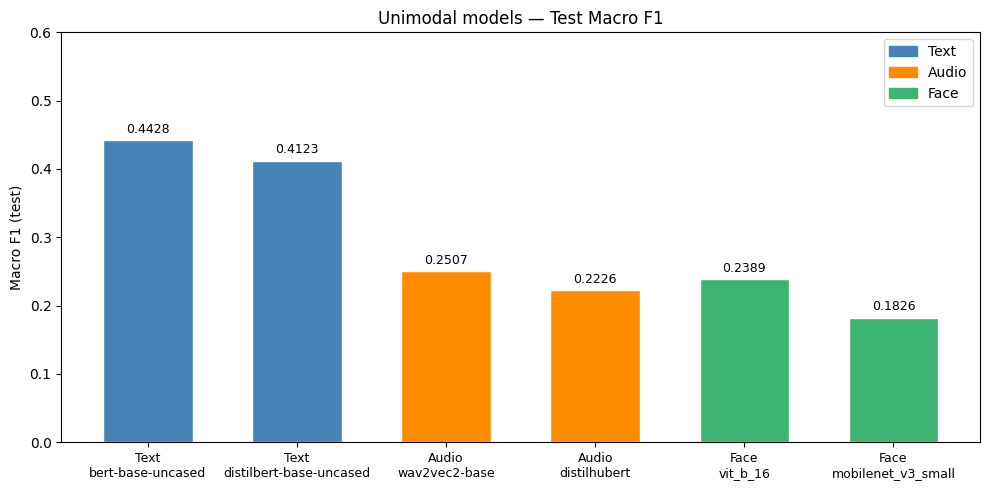

In [136]:
colors = {'Text': 'steelblue', 'Audio': 'darkorange', 'Face': 'mediumseagreen'}
bar_colors = [colors[m] for m in unimodal_df['modality']]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(unimodal_df))
bars = ax.bar(x, unimodal_df['test_macro_f1'], color=bar_colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{row.modality}\n{row.model.split('/')[-1]}" for row in unimodal_df.itertuples()],
    fontsize=9,
)
ax.set_ylim(0, 0.6)
ax.set_ylabel('Macro F1 (test)')
ax.set_title('Unimodal models — Test Macro F1')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors.items()], loc='upper right')

plt.tight_layout()
plt.show()

### 1d — Per-class breakdown for each unimodal model

In [137]:
CLASSES = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

def load_per_class(run_dir, json_name='eval_metrics.json'):
    path = os.path.join(run_dir, json_name)
    if not os.path.exists(path):
        return None
    data = load_json(path)
    report = data.get('report', data)  # eval_metrics may embed report or be a report itself
    rows = []
    for cls in CLASSES:
        if cls in report:
            r = report[cls]
            rows.append({'class': cls,
                         'precision': round(r['precision'], 4),
                         'recall':    round(r['recall'],    4),
                         'f1-score':  round(r['f1-score'],  4),
                         'support':   int(r['support'])})
    return pd.DataFrame(rows) if rows else None

# Show per-class tables for each model
for model_name in MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT, VERSION, slugify(model_name))
    report_path = os.path.join(run_dir, 'classification_report.json')
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Text) ──')
        print(df_pc.to_string(index=False))

for model_name in AUDIO_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_AUDIO, VERSION, slugify(model_name))
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Audio) ──')
        print(df_pc.to_string(index=False))

for model_name in FACE_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_FACE, VERSION, slugify(model_name))
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Face) ──')
        print(df_pc.to_string(index=False))

---
## 2 — Late Fusion Results

Two combos are evaluated:
- **Heavy**: BERT + wav2vec2-base + ViT-B/16
- **Light**: DistilBERT + DistilHuBERT + MobileNetV3-Small

Run `30_late_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

In [138]:
late_records = []

for combo in COMBOS:
    out_dir = os.path.join(LATE_FUSION_ROOT, combo)
    avg_path = os.path.join(out_dir, 'avg_ensemble_metrics.json')
    wt_path  = os.path.join(out_dir, 'weighted_ensemble_metrics.json')
    w_path   = os.path.join(out_dir, 'weights.json')

    if not os.path.exists(avg_path):
        print(f'  [skip] no late fusion results for combo={combo}')
        print(f'         → run notebook 30 with COMBO="{combo}"')
        continue

    avg_m = load_json(avg_path)
    wt_m  = safe_load_json(wt_path, {})
    w     = safe_load_json(w_path, {})

    late_records.append({
        'combo':              combo,
        'strategy':           'Average Ensemble',
        'text_w':             0.33, 'audio_w': 0.33, 'face_w': 0.33,
        'accuracy':           round(avg_m.get('accuracy', float('nan')), 4),
        'macro_f1':           round(avg_m.get('macro_f1', float('nan')), 4),
        'weighted_f1':        round(avg_m.get('weighted_f1', float('nan')), 4),
        'num_utterances':     avg_m.get('num_utterances', None),
    })
    late_records.append({
        'combo':              combo,
        'strategy':           'Weighted Ensemble',
        'text_w':             w.get('text', float('nan')),
        'audio_w':            w.get('audio', float('nan')),
        'face_w':             w.get('face', float('nan')),
        'accuracy':           round(wt_m.get('accuracy', float('nan')), 4),
        'macro_f1':           round(wt_m.get('macro_f1', float('nan')), 4),
        'weighted_f1':        round(wt_m.get('weighted_f1', float('nan')), 4),
        'num_utterances':     wt_m.get('num_utterances', None),
    })

if late_records:
    late_df = pd.DataFrame(late_records)
    display(late_df.to_string(index=False))
else:
    late_df = pd.DataFrame()
    print('No late fusion results available yet.')

'combo          strategy  text_w  audio_w  face_w  accuracy  macro_f1  weighted_f1  num_utterances\nheavy  Average Ensemble    0.33     0.33    0.33    0.6183    0.4168       0.5959            2481\nheavy Weighted Ensemble    0.40     0.10    0.50    0.6332    0.4597       0.6209            2481\nlight  Average Ensemble    0.33     0.33    0.33    0.6002    0.4067       0.5847            2481\nlight Weighted Ensemble    0.40     0.30    0.30    0.5994    0.4155       0.5897            2481'

### 2a — Late fusion confusion matrices

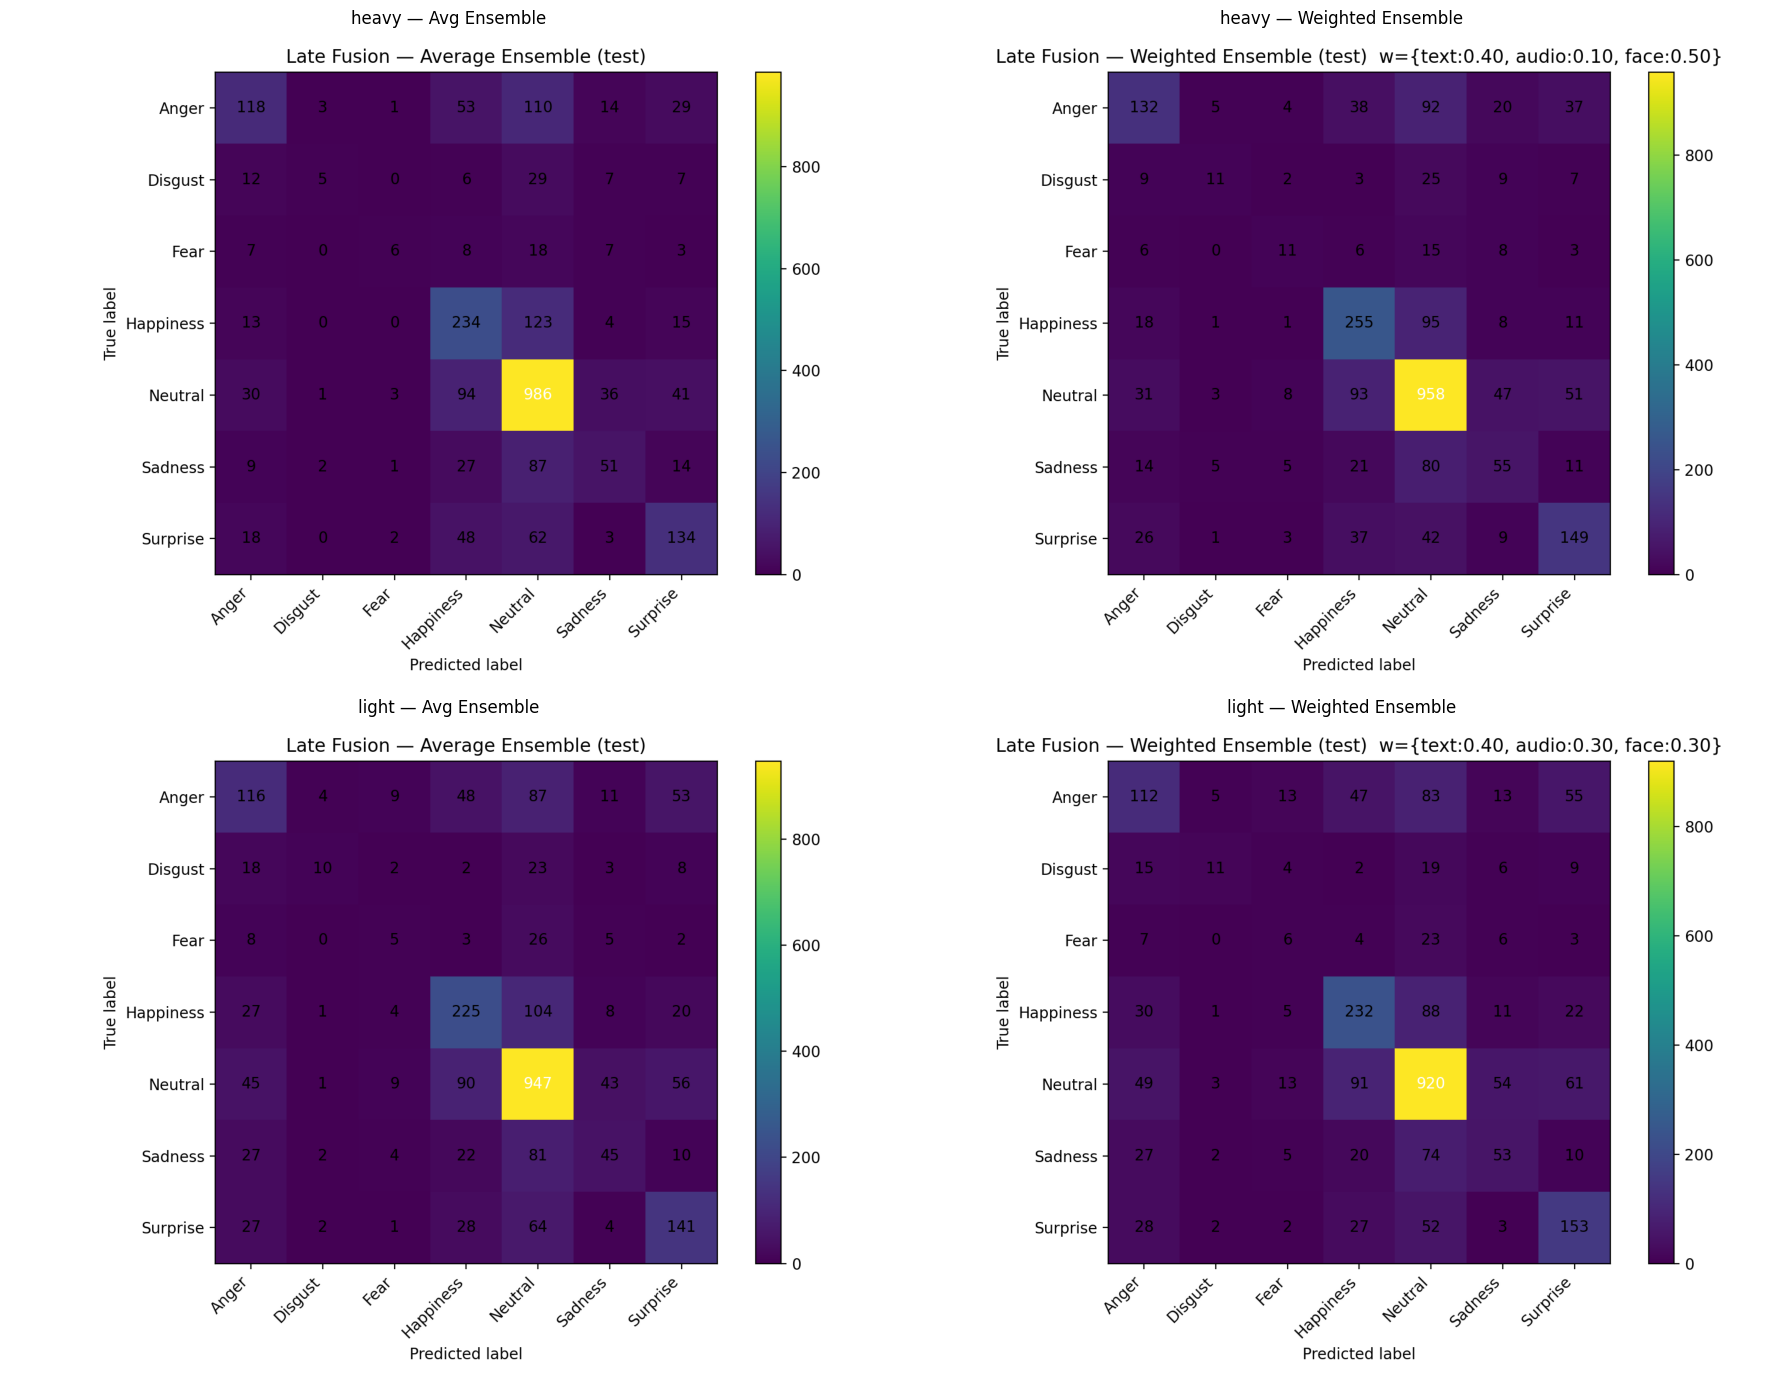

In [139]:
n_combos = sum(1 for c in COMBOS if os.path.exists(os.path.join(LATE_FUSION_ROOT, c, 'avg_ensemble_cm.png')))

if n_combos == 0:
    print('No late fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(n_combos, 2, figsize=(18, 7 * n_combos))
    if n_combos == 1:
        axes = [axes]  # ensure 2D indexing

    row = 0
    for combo in COMBOS:
        out_dir = os.path.join(LATE_FUSION_ROOT, combo)
        for col, name in enumerate(['avg_ensemble', 'weighted_ensemble']):
            img_path = os.path.join(out_dir, f'{name}_cm.png')
            ax = axes[row][col]
            if os.path.exists(img_path):
                ax.imshow(mpimg.imread(img_path))
                ax.set_title(f'{combo} — {name.replace("_", " ").title()}')
            else:
                ax.set_title(f'{combo} — {name} (not found)')
            ax.axis('off')
        row += 1

    plt.tight_layout()
    plt.show()

---
## 3 — Intermediate Fusion Results

Two combos are evaluated (same backbones as late fusion).

Run `31_intermediate_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

In [140]:
inter_records = []

for combo in COMBOS:
    out_dir = os.path.join(INTER_FUSION_ROOT, combo)
    test_path   = os.path.join(out_dir, 'test_metrics.json')
    config_path = os.path.join(out_dir, 'config.json')

    if not os.path.exists(test_path):
        print(f'  [skip] no intermediate fusion results for combo={combo}')
        print(f'         → run notebook 31 with COMBO="{combo}"')
        continue

    tm  = load_json(test_path)
    cfg = safe_load_json(config_path, {})

    emb_dims  = cfg.get('emb_dims', {})
    total_dim = cfg.get('total_dim', sum(emb_dims.values()) if emb_dims else None)

    inter_records.append({
        'combo':          combo,
        'emb_dim_total':  total_dim,
        'mlp_epochs':     cfg.get('mlp_epochs', None),
        'accuracy':       round(tm.get('accuracy', float('nan')), 4),
        'macro_f1':       round(tm.get('macro_f1', float('nan')), 4),
        'weighted_f1':    round(tm.get('weighted_f1', float('nan')), 4),
        'num_utterances': tm.get('num_utterances', None),
    })

if inter_records:
    inter_df = pd.DataFrame(inter_records)
    print(inter_df.to_string(index=False))
else:
    inter_df = pd.DataFrame()
    print('No intermediate fusion results available yet.')

combo  emb_dim_total  mlp_epochs  accuracy  macro_f1  weighted_f1  num_utterances
heavy           1792          50    0.6191    0.4533       0.6163            2481
light           2048          50    0.5784    0.4098       0.5792            2481


### 3a — Intermediate fusion training curves

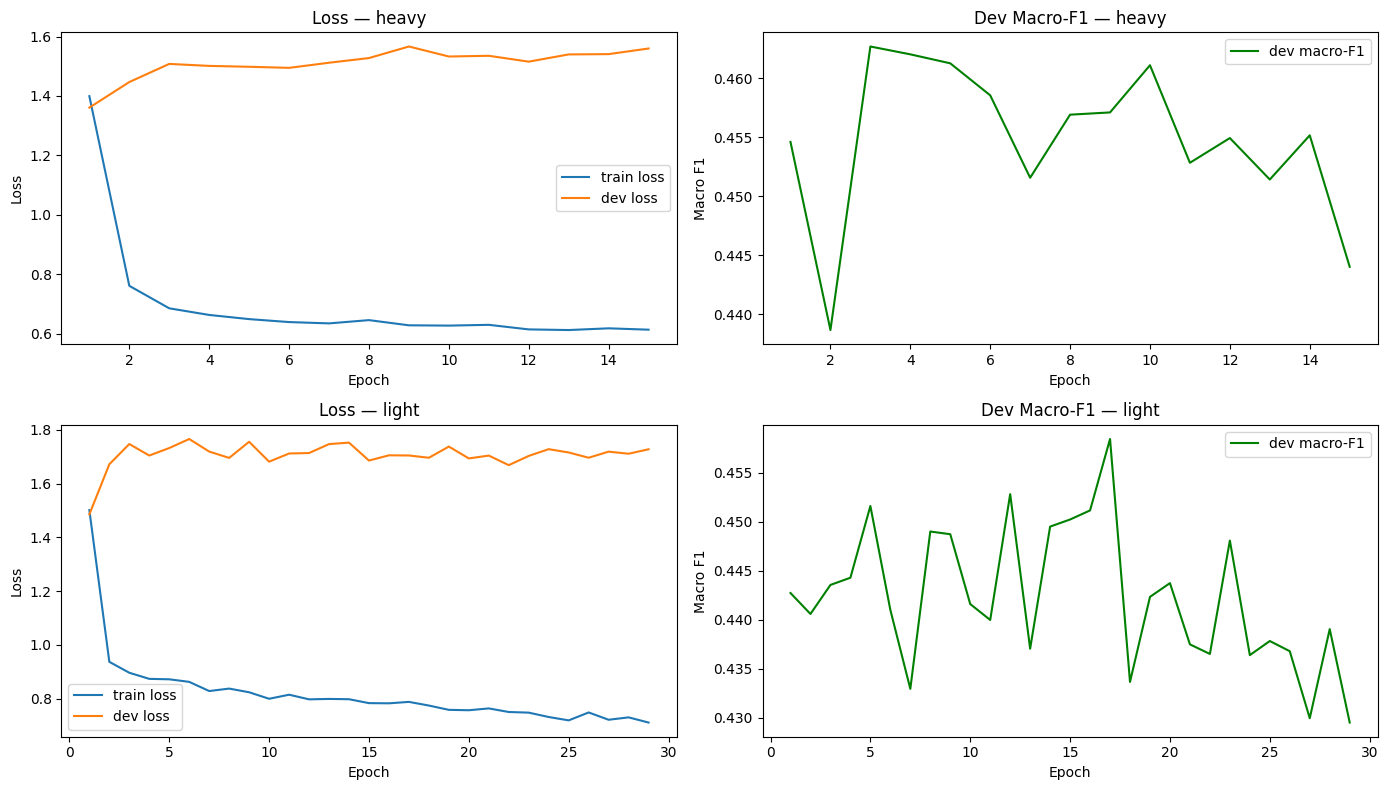

In [141]:
available_combos = [
    c for c in COMBOS
    if os.path.exists(os.path.join(INTER_FUSION_ROOT, c, 'history.csv'))
]

if not available_combos:
    print('No training history files found.')
else:
    fig, axes = plt.subplots(len(available_combos), 2,
                             figsize=(14, 4 * len(available_combos)), squeeze=False)

    for row, combo in enumerate(available_combos):
        hist = pd.read_csv(os.path.join(INTER_FUSION_ROOT, combo, 'history.csv'))

        ax1 = axes[row][0]
        ax1.plot(hist['epoch'], hist['train_loss'], label='train loss')
        ax1.plot(hist['epoch'], hist['dev_loss'],   label='dev loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'Loss — {combo}'); ax1.legend()

        ax2 = axes[row][1]
        ax2.plot(hist['epoch'], hist['dev_macro_f1'], color='green', label='dev macro-F1')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
        ax2.set_title(f'Dev Macro-F1 — {combo}'); ax2.legend()

    plt.tight_layout()
    plt.show()

### 3b — Intermediate fusion confusion matrices

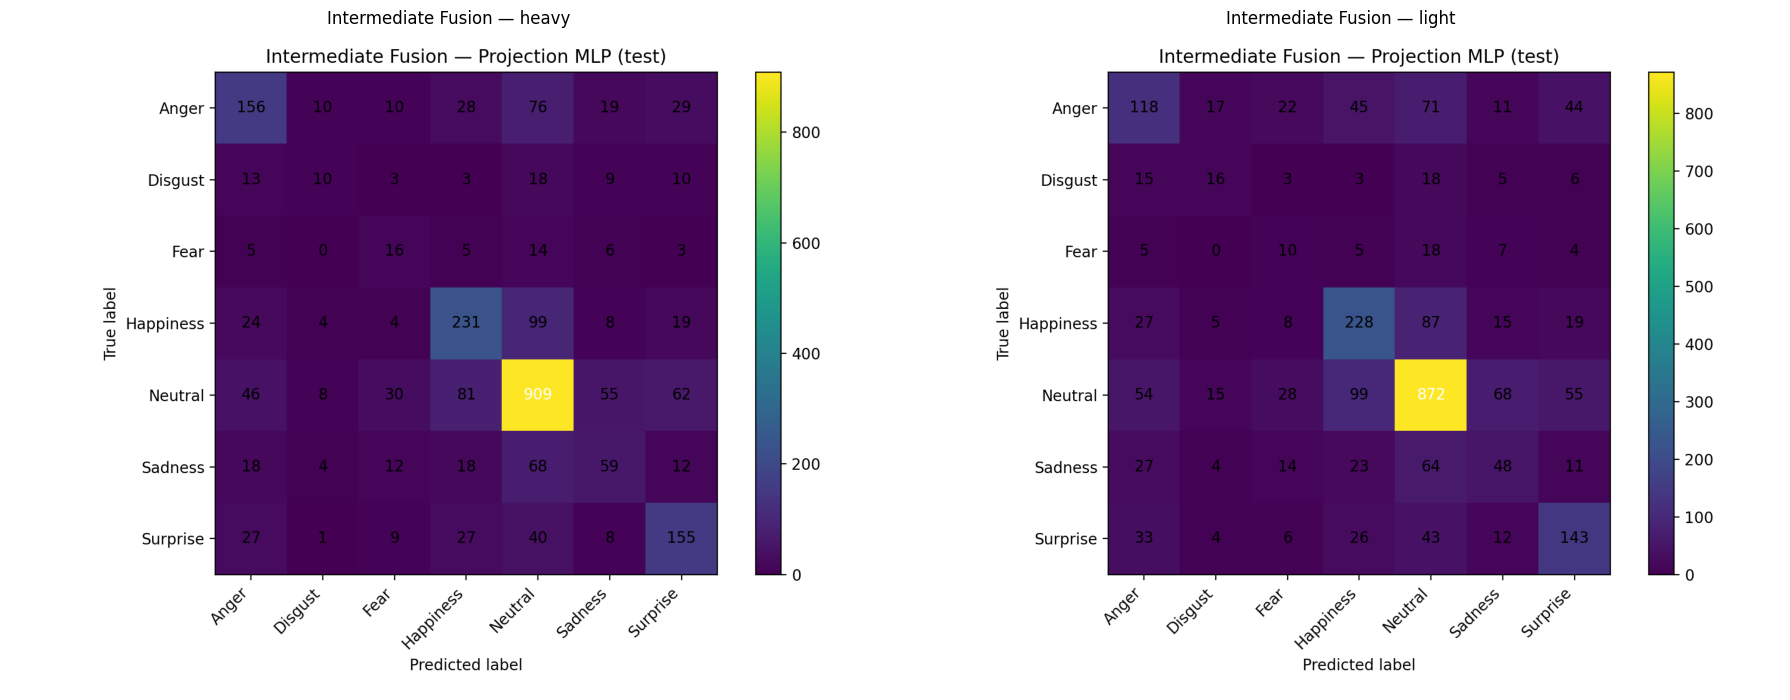

In [142]:
cm_combos = [
    c for c in COMBOS
    if os.path.exists(os.path.join(INTER_FUSION_ROOT, c, 'confusion_matrix_test.png'))
]

if not cm_combos:
    print('No intermediate fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(1, len(cm_combos), figsize=(9 * len(cm_combos), 7))
    if len(cm_combos) == 1:
        axes = [axes]

    for ax, combo in zip(axes, cm_combos):
        img_path = os.path.join(INTER_FUSION_ROOT, combo, 'confusion_matrix_test.png')
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f'Intermediate Fusion — {combo}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [143]:
gated_records = []

GATED_FUSION_ROOT = f'../experiments/fusion/gated'
VARIANTS = ['light', 'heavy']

# Load all combinations of backbone (COMBO) and gating (VARIANT)
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        test_path   = os.path.join(out_dir, 'test_metrics.json')
        config_path = os.path.join(out_dir, 'config.json')

        if not os.path.exists(test_path):
            print(f'  [skip] no gated fusion results for variant={variant}, combo={combo}')
            continue

        tm  = load_json(test_path)
        cfg = safe_load_json(config_path, {})

        emb_dims  = cfg.get('emb_dims', {})
        total_dim = cfg.get('total_dim', sum(emb_dims.values()) if emb_dims else None)

        gated_records.append({
            'combo':          combo,
            'variant':        variant,
            'emb_dim_total':  total_dim,
            'mlp_epochs':     cfg.get('mlp_epochs', None),
            'accuracy':       round(tm.get('accuracy', float('nan')), 4),
            'macro_f1':       round(tm.get('macro_f1', float('nan')), 4),
            'weighted_f1':    round(tm.get('weighted_f1', float('nan')), 4),
            'num_utterances': tm.get('num_utterances', None),
        })

if gated_records:
    gated_df = pd.DataFrame(gated_records)
    print(gated_df.to_string(index=False))
else:
    gated_df = pd.DataFrame()
    print('No gated fusion results available yet.')

combo variant  emb_dim_total mlp_epochs  accuracy  macro_f1  weighted_f1  num_utterances
heavy   light           1792       None    0.5857    0.4316       0.5954            2481
light   light           2048       None    0.5699    0.4157       0.5801            2481
heavy   heavy           1792       None    0.5885    0.4322       0.5965            2481
light   heavy           2048       None    0.5607    0.4090       0.5669            2481


### 4b — Gated fusion confusion matrices

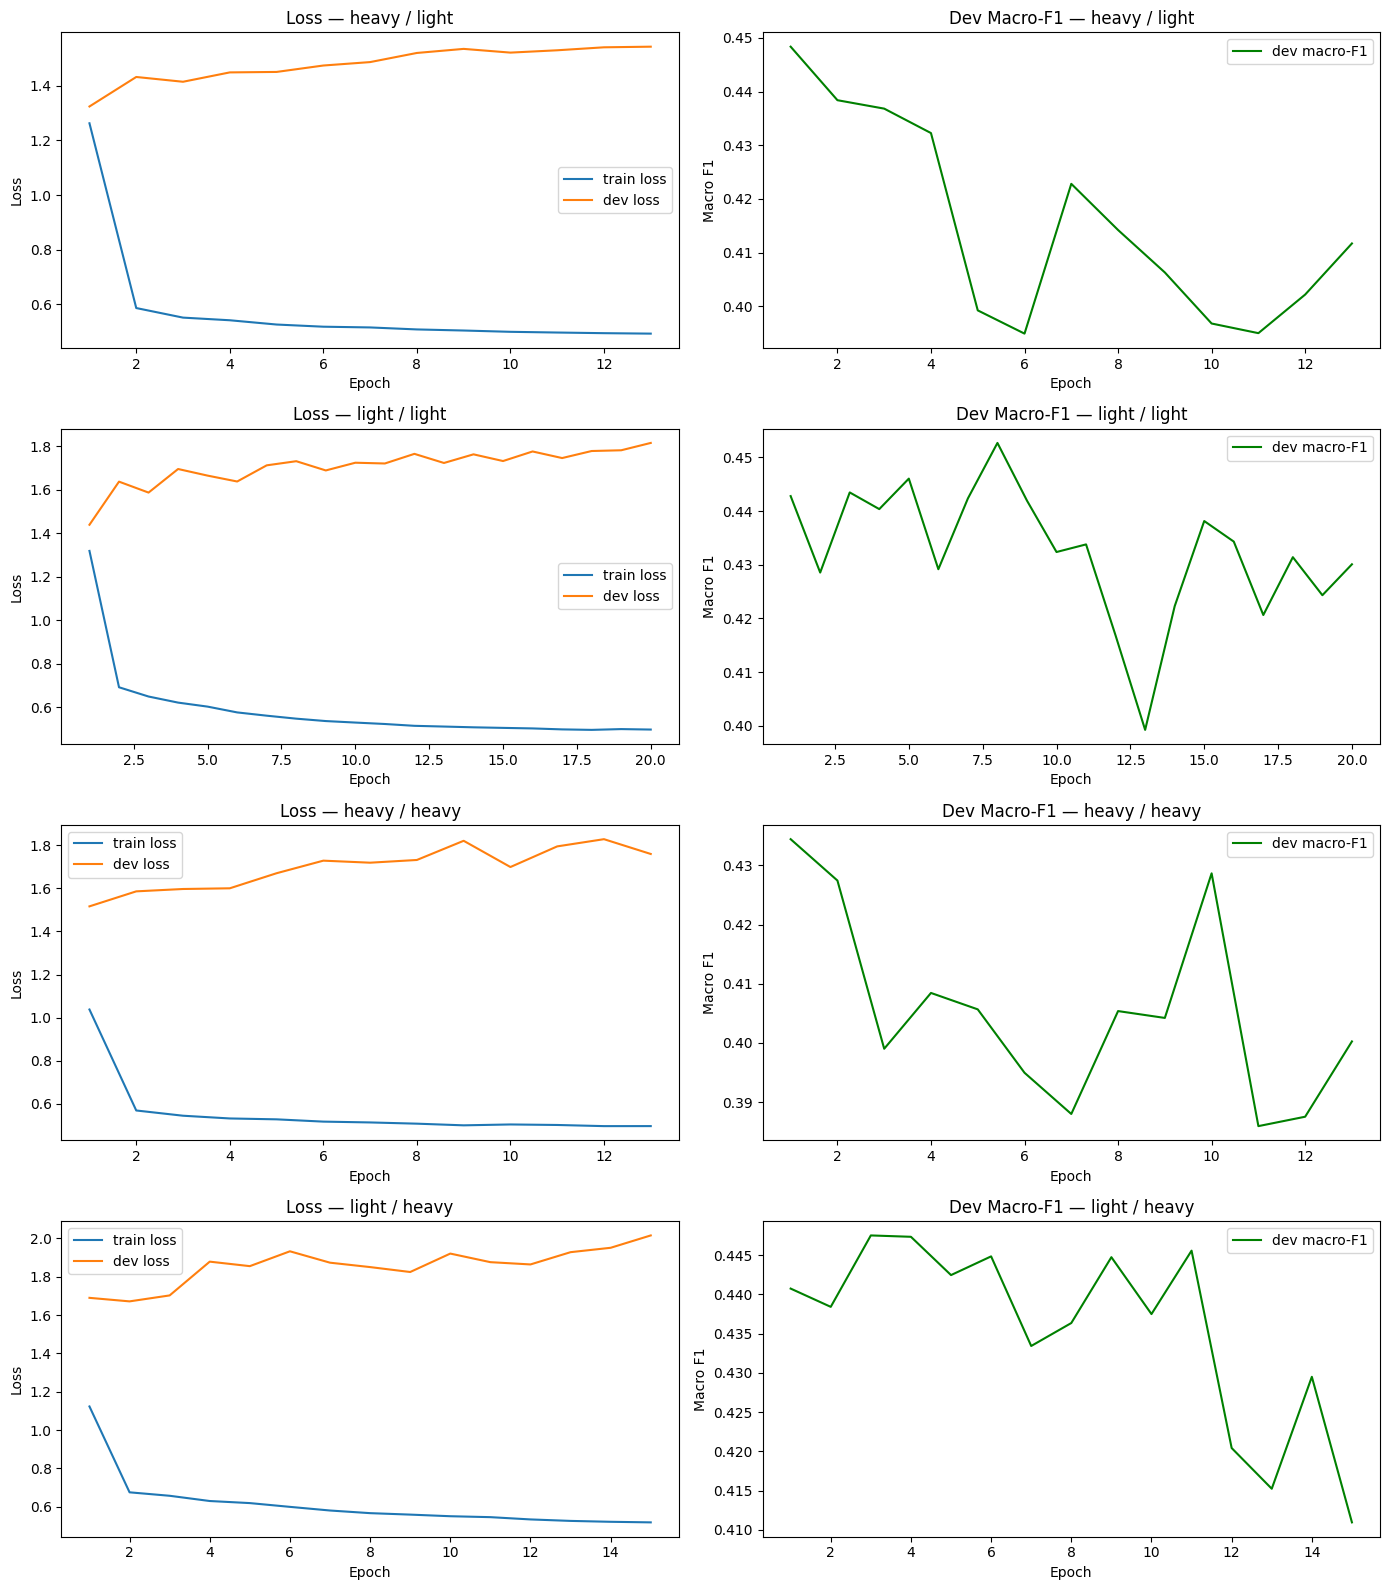

In [144]:
available_gated_combos = []
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        if os.path.exists(os.path.join(out_dir, 'history.csv')):
            available_gated_combos.append((variant, combo))

if not available_gated_combos:
    print('No gated fusion training history files found.')
else:
    fig, axes = plt.subplots(len(available_gated_combos), 2,
                             figsize=(14, 4 * len(available_gated_combos)), squeeze=False)

    for row, (variant, combo) in enumerate(available_gated_combos):
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        hist = pd.read_csv(os.path.join(out_dir, 'history.csv'))

        ax1 = axes[row][0]
        ax1.plot(hist['epoch'], hist['train_loss'], label='train loss')
        ax1.plot(hist['epoch'], hist['dev_loss'],   label='dev loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'Loss — {combo} / {variant}'); ax1.legend()

        ax2 = axes[row][1]
        ax2.plot(hist['epoch'], hist['dev_macro_f1'], color='green', label='dev macro-F1')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
        ax2.set_title(f'Dev Macro-F1 — {combo} / {variant}'); ax2.legend()

    plt.tight_layout()
    plt.show()

### 4a — Gated fusion training curves

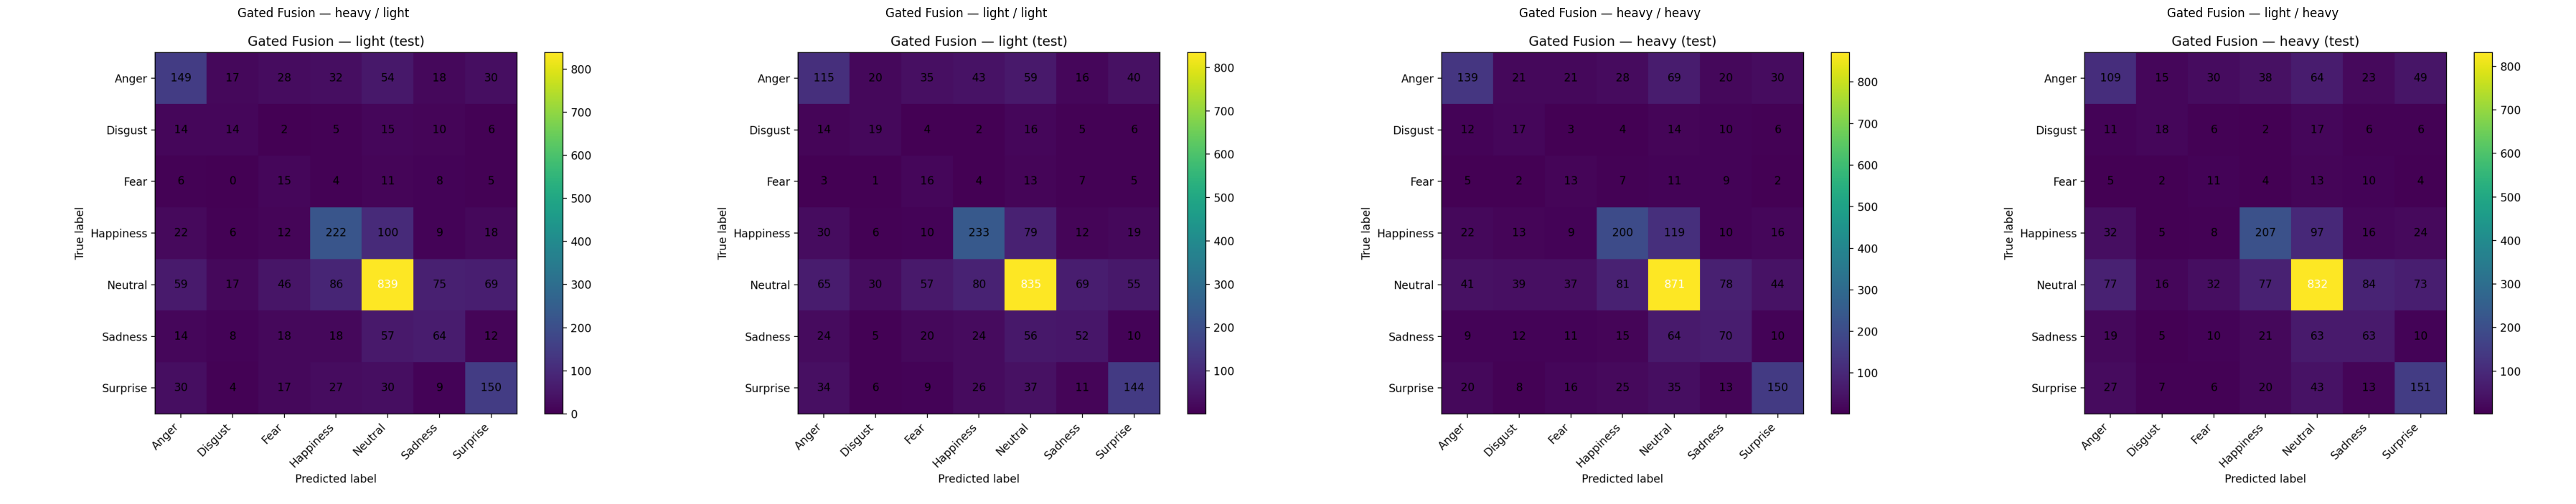

In [145]:
cm_gated_combos = []
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        if os.path.exists(os.path.join(out_dir, 'confusion_matrix_test.png')):
            cm_gated_combos.append((variant, combo))

if not cm_gated_combos:
    print('No gated fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(1, len(cm_gated_combos), figsize=(9 * len(cm_gated_combos), 7))
    if len(cm_gated_combos) == 1:
        axes = [axes]

    for ax, (variant, combo) in zip(axes, cm_gated_combos):
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        img_path = os.path.join(out_dir, 'confusion_matrix_test.png')
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f'Gated Fusion — {combo} / {variant}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

---
## 4 — Gated Fusion Results

Two combos are evaluated (same backbones as late and intermediate fusion).

Run `32_gated_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

---
## 5 — Master Comparison Table

All methods side-by-side, sorted by Test Macro F1.

In [146]:
master_rows = []

# ── Unimodal ──────────────────────────────────────────────────────────────────
for row in unimodal_df.itertuples():
    master_rows.append({
        'Method':       f'{row.modality} — {row.model.split("/")[-1]}',
        'Type':         'Unimodal',
        'Combo':        '—',
        'Variant':      '—',
        'Accuracy':     row.test_accuracy,
        'Macro F1':     row.test_macro_f1,
        'Weighted F1':  row.test_weighted_f1,
    })

# ── Late Fusion ───────────────────────────────────────────────────────────────
for row in late_df.itertuples() if not late_df.empty else []:
    master_rows.append({
        'Method':       f'Late Fusion — {row.strategy}',
        'Type':         'Late Fusion',
        'Combo':        row.combo,
        'Variant':      '—',
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

# ── Intermediate Fusion ───────────────────────────────────────────────────────
for row in inter_df.itertuples() if not inter_df.empty else []:
    master_rows.append({
        'Method':       'Intermediate Fusion — MLP',
        'Type':         'Intermediate Fusion',
        'Combo':        row.combo,
        'Variant':      '—',
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

# ── Gated Fusion ──────────────────────────────────────────────────────────────
for row in gated_df.itertuples() if not gated_df.empty else []:
    master_rows.append({
        'Method':       'Gated Fusion — Gated MLP',
        'Type':         'Gated Fusion',
        'Combo':        row.combo,
        'Variant':      row.variant,
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

master_df = pd.DataFrame(master_rows)
master_df = master_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
master_df

,Method,Type,Combo,Variant,Accuracy,Macro F1,Weighted F1
0,Late Fusion — Weighted Ensemble,Late Fusion,heavy,—,0.6332,0.4597,0.6209
1,Intermediate Fusion — MLP,Intermediate Fusion,heavy,—,0.6191,0.4533,0.6163
2,Text — bert-base-uncased,Unimodal,—,—,0.6165,0.4428,0.6085
3,Gated Fusion — Gated MLP,Gated Fusion,heavy,heavy,0.5885,0.4322,0.5965
4,Gated Fusion — Gated MLP,Gated Fusion,heavy,light,0.5857,0.4316,0.5954
5,Late Fusion — Average Ensemble,Late Fusion,heavy,—,0.6183,0.4168,0.5959
6,Gated Fusion — Gated MLP,Gated Fusion,light,light,0.5699,0.4157,0.5801
7,Late Fusion — Weighted Ensemble,Late Fusion,light,—,0.5994,0.4155,0.5897
8,Text — distilbert-base-uncased,Unimodal,—,—,0.5877,0.4123,0.5885
9,Intermediate Fusion — MLP,Intermediate Fusion,light,—,0.5784,0.4098,0.5792


### 5a — Comparison bar chart

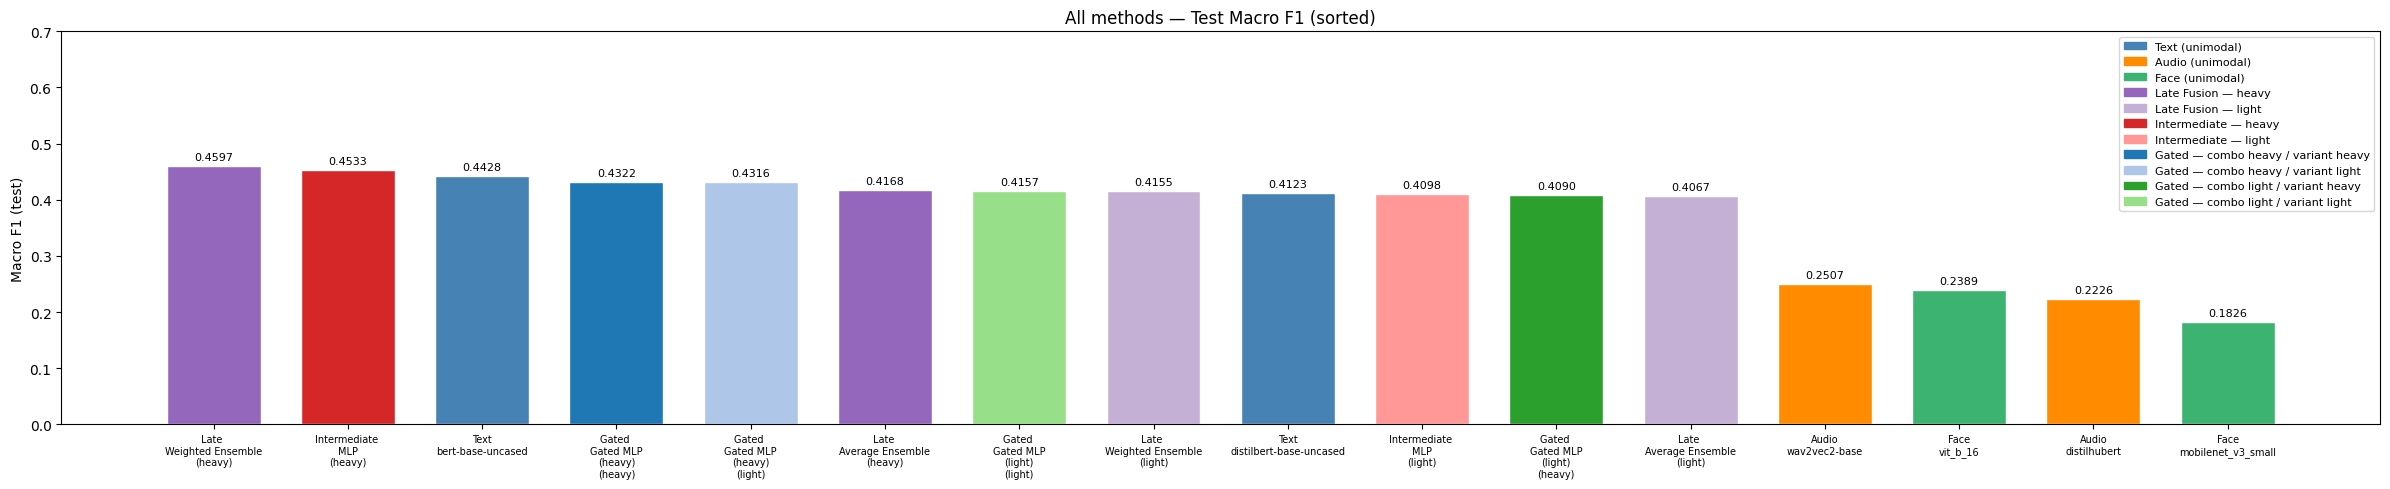

In [147]:
type_colors = {
    'Unimodal':             {'Text': 'steelblue', 'Audio': 'darkorange', 'Face': 'mediumseagreen'},
    'Late Fusion':          {'heavy': '#9467bd', 'light': '#c5b0d5'},
    'Intermediate Fusion':  {'heavy': '#d62728', 'light': '#ff9896'},
    'Gated Fusion':         {('heavy', 'heavy'): '#1f77b4', ('heavy', 'light'): '#aec7e8',
                             ('light', 'heavy'): '#2ca02c', ('light', 'light'): '#98df8a'},
}

def row_color(row):
    t = row['Type']
    c = row['Combo']
    v = row['Variant']
    if t == 'Unimodal':
        mod = row['Method'].split(' — ')[0]
        return type_colors['Unimodal'].get(mod, 'gray')
    elif t == 'Gated Fusion':
        return type_colors.get(t, {}).get((c, v), 'gray')
    return type_colors.get(t, {}).get(c, 'gray')

bar_colors = [row_color(r) for _, r in master_df.iterrows()]

fig, ax = plt.subplots(figsize=(max(12, len(master_df) * 1.5), 5))
x = range(len(master_df))
bars = ax.bar(x, master_df['Macro F1'], color=bar_colors, edgecolor='white', width=0.7)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)

labels = []
for _, row in master_df.iterrows():
    m = row['Method'].replace('Fusion — ', '\n').replace(' — ', '\n')
    c = f"({row['Combo']})" if row['Combo'] != '—' else ''
    v = f"({row['Variant']})" if row['Variant'] != '—' else ''
    label_str = m
    if c:
        label_str = f'{m}\n{c}'
    if v:
        label_str = f'{label_str}\n{v}' if c else f'{m}\n{v}'
    labels.append(label_str)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylim(0, 0.7)
ax.set_ylabel('Macro F1 (test)')
ax.set_title('All methods — Test Macro F1 (sorted)')

from matplotlib.patches import Patch
legend_elems = [
    Patch(color='steelblue',   label='Text (unimodal)'),
    Patch(color='darkorange',  label='Audio (unimodal)'),
    Patch(color='mediumseagreen', label='Face (unimodal)'),
    Patch(color='#9467bd',     label='Late Fusion — heavy'),
    Patch(color='#c5b0d5',     label='Late Fusion — light'),
    Patch(color='#d62728',     label='Intermediate — heavy'),
    Patch(color='#ff9896',     label='Intermediate — light'),
    Patch(color='#1f77b4',     label='Gated — combo heavy / variant heavy'),
    Patch(color='#aec7e8',     label='Gated — combo heavy / variant light'),
    Patch(color='#2ca02c',     label='Gated — combo light / variant heavy'),
    Patch(color='#98df8a',     label='Gated — combo light / variant light'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6 — Learning curves (unimodal models)

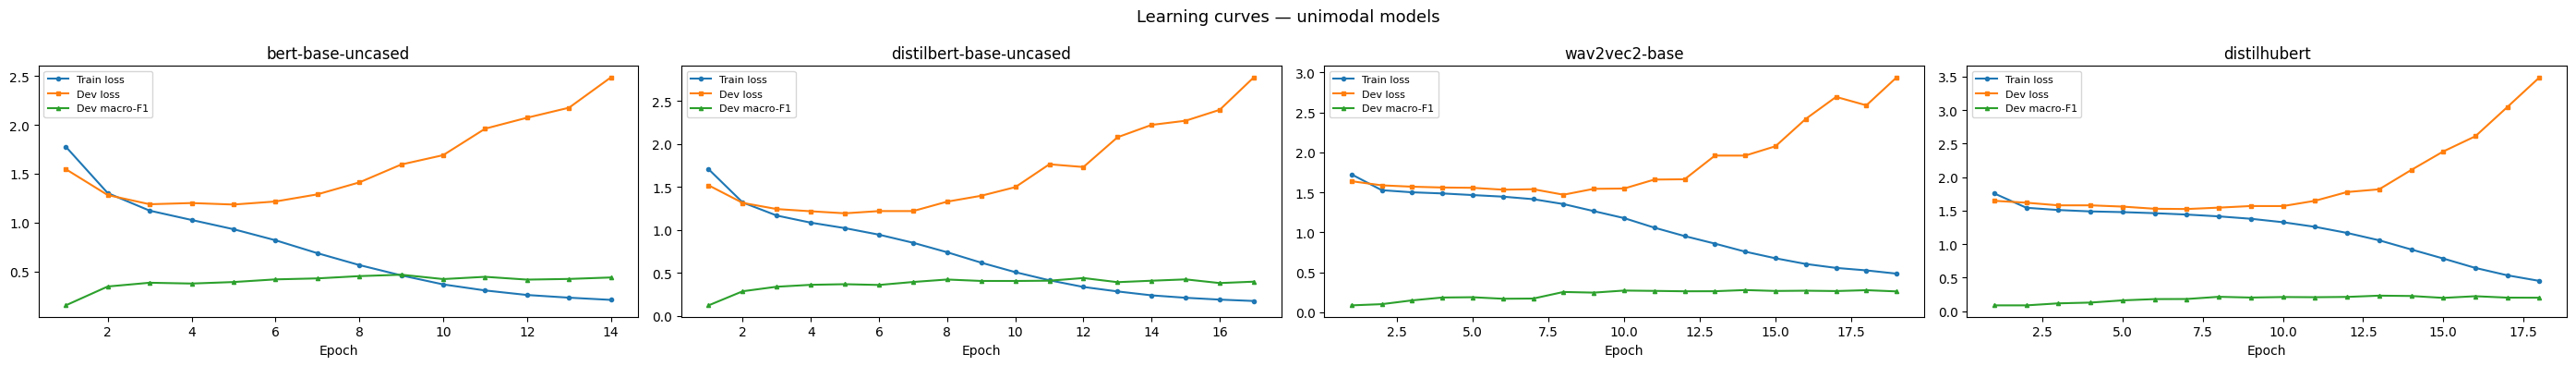

In [148]:
histories = {}
all_models = [
    (EXP_ROOT,       MODELS_TO_RUN),
    (EXP_ROOT_AUDIO, AUDIO_MODELS_TO_RUN),
]
# Face models use a different history key name
for root, model_list in all_models:
    for model_name in model_list:
        h_path = os.path.join(root, VERSION, slugify(model_name), 'history.csv')
        if os.path.exists(h_path):
            histories[model_name] = pd.read_csv(h_path)

if not histories:
    print('No history.csv files found.')
else:
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 4), squeeze=False)
    for ax, (model_name, hist) in zip(axes[0], histories.items()):
        ax.plot(hist['epoch'], hist['train_loss'],   label='Train loss',   marker='o', markersize=3)
        ax.plot(hist['epoch'], hist['dev_loss'],     label='Dev loss',     marker='s', markersize=3)
        ax.plot(hist['epoch'], hist['dev_macro_f1'], label='Dev macro-F1', marker='^', markersize=3)
        ax.set_xlabel('Epoch')
        ax.set_title(model_name.split('/')[-1])
        ax.legend(fontsize=8)
    plt.suptitle('Learning curves — unimodal models', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 10 — Confusion Matrices: Save all to file

Copies every `confusion_matrix_test.png` / `*_cm.png` to `results/confusion_matrices/`,
writes a combined text classification report, and renders a grid figure.

16/16 confusion matrix images found.
Text report  → ../results/confusion_matrices\_all_classification_reports.txt


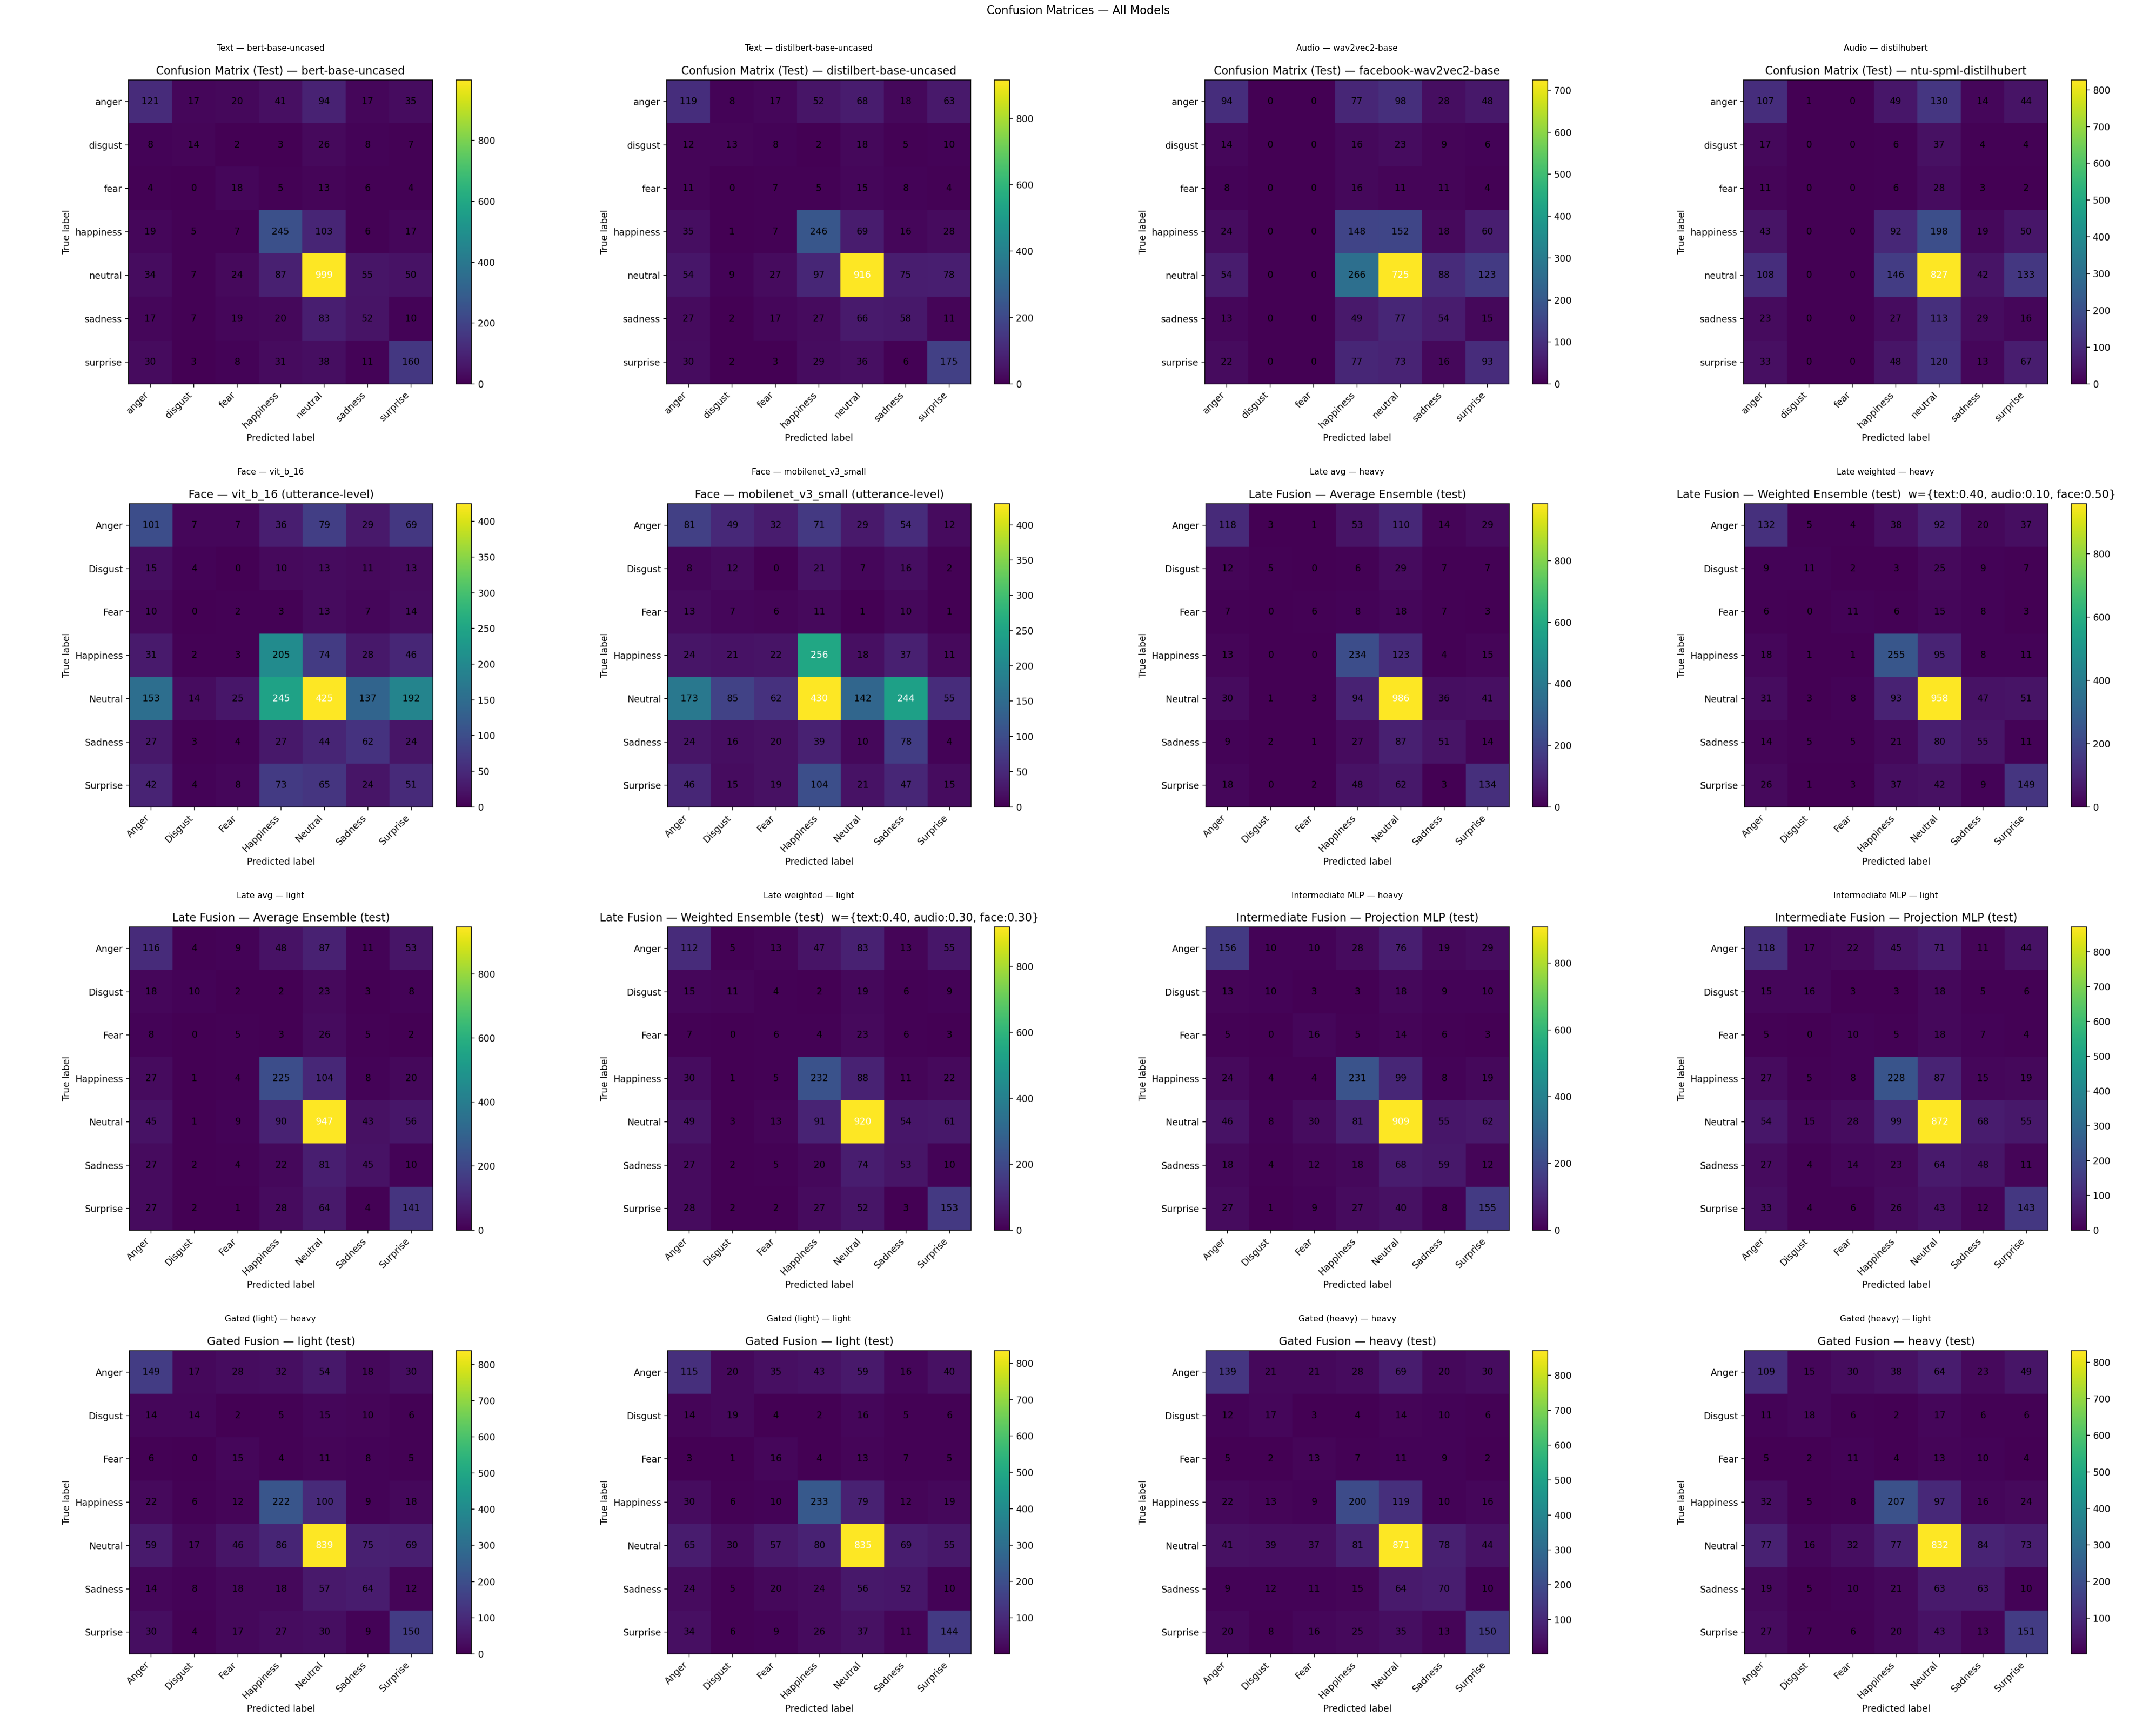

Grid image   → ../results/confusion_matrices\_grid_all.png


In [149]:
# 10 — Save all confusion matrices (images + text reports)
# Collects existing PNG CMs from every experiment, copies them to
# results/confusion_matrices/, builds a grid, and writes a text report.
import re, math, shutil

CM_OUT = '../results/confusion_matrices'
os.makedirs(CM_OUT, exist_ok=True)

CLASSES  = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
_GATED_B = '../experiments/fusion/gated'  # /{variant}/{VERSION}/{combo}

# Collect (label, cm_png_path, report_json_path)
entries = []

for model_name in MODELS_TO_RUN:
    rd = os.path.join(EXP_ROOT, VERSION, slugify(model_name))
    entries.append((
        f'Text — {model_name.split("/")[-1]}',
        os.path.join(rd, 'confusion_matrix_test.png'),
        os.path.join(rd, 'classification_report_test.json'),
    ))

for model_name in AUDIO_MODELS_TO_RUN:
    rd = os.path.join(EXP_ROOT_AUDIO, VERSION, slugify(model_name))
    entries.append((
        f'Audio — {model_name.split("/")[-1]}',
        os.path.join(rd, 'confusion_matrix_test.png'),
        os.path.join(rd, 'classification_report_test.json'),
    ))

for model_name in FACE_MODELS_TO_RUN:
    rd = os.path.join(EXP_ROOT_FACE, VERSION, slugify(model_name))
    entries.append((
        f'Face — {model_name.split("/")[-1]}',
        os.path.join(rd, 'confusion_matrix_test.png'),
        os.path.join(rd, 'classification_report_test.json'),
    ))

for combo in COMBOS:
    rd = os.path.join(LATE_FUSION_ROOT, combo)
    for tag, base in [('avg', 'avg_ensemble'), ('weighted', 'weighted_ensemble')]:
        entries.append((
            f'Late {tag} — {combo}',
            os.path.join(rd, f'{base}_cm.png'),
            os.path.join(rd, f'{base}_report.json'),
        ))

for combo in COMBOS:
    rd = os.path.join(INTER_FUSION_ROOT, combo)
    entries.append((
        f'Intermediate MLP — {combo}',
        os.path.join(rd, 'confusion_matrix_test.png'),
        os.path.join(rd, 'classification_report.json'),
    ))

for fv in VARIANTS:
    for bc in COMBOS:
        rd = os.path.join(_GATED_B, fv, VERSION, bc)
        entries.append((
            f'Gated ({fv}) — {bc}',
            os.path.join(rd, 'confusion_matrix_test.png'),
            os.path.join(rd, 'classification_report.json'),
        ))

# Copy PNGs
available = [(lbl, png, rep) for lbl, png, rep in entries if os.path.exists(png)]
print(f'{len(available)}/{len(entries)} confusion matrix images found.')

for label, png_path, _ in available:
    fname = re.sub(r'[^\w\-]', '_', label).strip('_') + '.png'
    shutil.copy2(png_path, os.path.join(CM_OUT, fname))

# Text classification report file
def _report_block(label, rep_path, classes):
    sep = '=' * 64
    if not os.path.exists(rep_path):
        return f'\n{sep}\n  {label}  [report not found]\n'
    rep = {k.lower(): v for k, v in load_json(rep_path).items()}
    lines = [
        f'\n{sep}', f'  {label}', sep,
        f"  {'Class':15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>9}",
        f"  {'-'*56}",
    ]
    for cls in classes:
        if cls in rep:
            r = rep[cls]
            lines.append(
                f"  {cls:15} {r['precision']:>10.4f} {r['recall']:>10.4f}"
                f" {r['f1-score']:>10.4f} {int(r['support']):>9}"
            )
    for key in ('macro avg', 'weighted avg'):
        if key in rep:
            r = rep[key]
            lines.append(
                f"  {key:15} {r['precision']:>10.4f} {r['recall']:>10.4f}"
                f" {r['f1-score']:>10.4f} {int(r.get('support', 0)):>9}"
            )
    if 'accuracy' in rep:
        lines.append(f"\n  Accuracy : {rep['accuracy']:.4f}")
    return '\n'.join(lines)

txt_path = os.path.join(CM_OUT, '_all_classification_reports.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('Classification Reports — All Models and Fusion Configurations\n')
    f.write(f'Generated : {pd.Timestamp.now().isoformat()}\n')
    for label, _, rep_path in entries:
        f.write(_report_block(label, rep_path, CLASSES))
        f.write('\n')
print(f'Text report  → {txt_path}')

# Grid image
ncols = 4
nrows = math.ceil(len(available) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 8 * nrows))
axes = np.array(axes).reshape(-1)

for i, (label, png_path, _) in enumerate(available):
    axes[i].imshow(mpimg.imread(png_path))
    axes[i].set_title(label, fontsize=11)
    axes[i].axis('off')
for j in range(len(available), len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, y=1.005)
plt.tight_layout()
grid_path = os.path.join(CM_OUT, '_grid_all.png')
plt.savefig(grid_path, bbox_inches='tight', dpi=100)
plt.show()
print(f'Grid image   → {grid_path}')


---
## 11 — Parametric: Unimodal vs Multimodal — Correction Examples

Set `MULTIMODAL`, `BACKBONE`, `UNIMODAL`, and `EXPLAINABILITY` at the top of the
next cell.  Uses the pre-computed intermediate-fusion embedding cache — no backbone
is loaded.  Results saved to `results/examples/{MULTIMODAL}_{BACKBONE}_vs_{UNIMODAL}/`.


In [150]:
# ──────────────────────────────────────────────────────────────────────────────
# 11 — Parametric unimodal-vs-multimodal correction examples
#
# Pick any multimodal model and any unimodal to compare against.
# Finds: (A) unimodal wrong + multimodal right, (B) unimodal right + multimodal wrong.
# Optionally shows per-modality confidence or gate values.
# Saves results to  results/examples/{MULTIMODAL}_{BACKBONE}_vs_{UNIMODAL}/.
# ──────────────────────────────────────────────────────────────────────────────
import os, torch, numpy as np, pandas as pd
from safetensors import safe_open
from src.evaluation.intermediate_fusion import ProjectionFusionMLP
from src.evaluation.gated_fusion import GatedFusionLight, GatedFusionHeavy

# ── PARAMETERS ─────────────────────────────────────────────────────────────────
# MULTIMODAL — fusion model to use as the multimodal predictor
#   'intermediate'       ProjectionFusionMLP trained on cached backbone embeddings
#   'late_avg'           Average of the three unimodal logit vectors (no learned head)
#   'late_weighted'      Weighted average using weights saved in experiments/fusion/late
#   'gated_gmu'          GatedFusionLight  (GMU soft-gating, light fusion variant)
#   'gated_transformer'  GatedFusionHeavy  (cross-modal Transformer, heavy fusion variant)
MULTIMODAL = 'intermediate'

# BACKBONE — backbone pair shared by all models
#   'heavy'  BERT-base + wav2vec2-base + ViT-B/16
#   'light'  DistilBERT-base + DistilHuBERT + MobileNetV3-Small
BACKBONE = 'heavy'

# UNIMODAL — which unimodal modality to compare against
#   'text'   text model  (BERT or DistilBERT, depending on BACKBONE)
#   'audio'  audio model (wav2vec2-base or DistilHuBERT)
#   'face'   face model  (ViT-B/16 or MobileNetV3-Small)
UNIMODAL = 'text'

# EXPLAINABILITY — what extra info to show per example
#   'none'        only prediction labels
#   'confidence'  per-modality softmax confidence for each example
#   'gates'       per-modality gate weights (gated models only; falls back to 'confidence')
EXPLAINABILITY = 'confidence'

# N_EXAMPLES — max examples for case A (one per true emotion class)
N_EXAMPLES = 5

# SAVE — write a .txt report to results/examples/
SAVE = True
# ──────────────────────────────────────────────────────────────────────────────

EMOTIONS  = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
ID2EMO    = {i: e for i, e in enumerate(EMOTIONS)}
TEST_CSV  = '../Data/MELD.Raw/test_sent_emo.csv'
_GATED_B  = '../experiments/fusion/gated'
CACHE_ROOT = os.path.join(INTER_FUSION_ROOT, BACKBONE, 'cache')

# ── 1. Load & align embedding caches ─────────────────────────────────────────
def _npz(name):
    d = np.load(os.path.join(CACHE_ROOT, f'{name}_test.npz'))
    return d['embeddings'], d['labels'].astype(int), d['d_ids'].astype(int), d['u_ids'].astype(int)

te, tl, td, tu = _npz('text')
ae, al, ad, au = _npz('audio')
fe, fl, fd, fu = _npz('face')
print(f'Cache sizes — text:{len(tl)}  audio:{len(al)}  face:{len(fl)}')

common = sorted(
    set(zip(td.tolist(), tu.tolist()))
    & set(zip(ad.tolist(), au.tolist()))
    & set(zip(fd.tolist(), fu.tolist()))
)
print(f'Aligned samples: {len(common)}')

def _sel(embs, dids, uids):
    m = {(int(d), int(u)): i for i, (d, u) in enumerate(zip(dids, uids))}
    return embs[[m[k] for k in common]]

txt_e = _sel(te, td, tu)
aud_e = _sel(ae, ad, au)
fac_e = _sel(fe, fd, fu)
lbl_m = {(int(d), int(u)): int(l) for d, u, l in zip(td, tu, tl)}
true  = np.array([lbl_m[k] for k in common])
keys_d = np.array([k[0] for k in common])
keys_u = np.array([k[1] for k in common])

# ── 2. Unimodal logits (linear head only — no backbone loaded) ────────────────
cfg_ex = load_json(os.path.join(INTER_FUSION_ROOT, BACKBONE, 'config.json'))

def _hf_head(run_dir_rel, weight_key='classifier.weight', bias_key='classifier.bias'):
    """Load a single HuggingFace linear head from model.safetensors."""
    sf = os.path.join(run_dir_rel, 'model', 'model.safetensors')
    with safe_open(sf, framework='pt', device='cpu') as f:
        W = f.get_tensor(weight_key)
        b = f.get_tensor(bias_key)
    return W, b

def _pt_head(ckpt_path, weight_key, bias_key):
    """Load a linear head from a plain PyTorch checkpoint (.pt)."""
    sd = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    return sd[weight_key], sd[bias_key]

def _logits(embs, W, b):
    return torch.tensor(embs, dtype=torch.float32) @ W.T + b

# Text head
txt_slug = os.path.basename(cfg_ex['text_run_dir'].replace('\\', '/'))
W_t, b_t = _hf_head(os.path.join(EXP_ROOT, VERSION, txt_slug))
txt_logits = _logits(txt_e, W_t, b_t)

# Audio head
aud_slug = os.path.basename(cfg_ex['audio_run_dir'].replace('\\', '/'))
W_a, b_a = _hf_head(os.path.join(EXP_ROOT_AUDIO, VERSION, aud_slug))
aud_logits = _logits(aud_e, W_a, b_a)

# Face head (PyTorch .pt checkpoint — two possible architectures)
fac_slug = os.path.basename(cfg_ex['face_run_dir'].replace('\\', '/'))
fac_ckpt = os.path.join(EXP_ROOT_FACE, VERSION, fac_slug, 'model', 'best_model.pt')
if 'vit' in fac_slug:
    # ViT-B/16: head at model.heads.head  (Linear 768→7)
    W_f, b_f = _pt_head(fac_ckpt, 'heads.head.1.weight', 'heads.head.1.bias')
else:
    # MobileNetV3-Small: last layer of model.classifier Sequential  (Linear 1024→7)
    W_f, b_f = _pt_head(fac_ckpt, 'classifier.3.weight', 'classifier.3.bias')
fac_logits = _logits(fac_e, W_f, b_f)

# ── 3. Multimodal logits ──────────────────────────────────────────────────────
def _run_mlp(model, ckpt, d):
    model.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    model.eval()
    with torch.no_grad():
        return model({m: torch.tensor(d[m], dtype=torch.float32) for m in d})

emb_dims = cfg_ex['emb_dims']
feats    = {'text': txt_e, 'audio': aud_e, 'face': fac_e}

if MULTIMODAL == 'intermediate':
    mlp = ProjectionFusionMLP(
        in_dims=emb_dims,
        d_proj=cfg_ex.get('mlp_d_proj', 128),
        d_hidden=cfg_ex.get('mlp_d_hidden', 256),
        num_classes=7, dropout=0.0, modality_dropout=0.0,
    )
    fus_logits = _run_mlp(mlp, os.path.join(INTER_FUSION_ROOT, BACKBONE, 'fusion_mlp.pt'), feats)

elif MULTIMODAL == 'late_avg':
    fus_logits = (txt_logits + aud_logits + fac_logits) / 3.0

elif MULTIMODAL == 'late_weighted':
    w = load_json(os.path.join(LATE_FUSION_ROOT, BACKBONE, 'weights.json'))
    fus_logits = w['text'] * txt_logits + w['audio'] * aud_logits + w['face'] * fac_logits

elif MULTIMODAL in ('gated_gmu', 'gated_transformer'):
    fv = 'light' if MULTIMODAL == 'gated_gmu' else 'heavy'
    cfg_g = load_json(os.path.join(_GATED_B, fv, VERSION, BACKBONE, 'config.json'))
    ckpt_g = os.path.join(_GATED_B, fv, VERSION, BACKBONE, 'gated_fusion.pt')
    if MULTIMODAL == 'gated_gmu':
        model_g = GatedFusionLight(
            in_dims=emb_dims, d_proj=cfg_g.get('d_proj', 128),
            d_hidden=cfg_g.get('d_hidden', 128), num_classes=7,
            dropout=0.0,
        )
    else:
        model_g = GatedFusionHeavy(
            in_dims=emb_dims, d_model=cfg_g.get('d_model', 256),
            nhead=cfg_g.get('nhead', 4), num_layers=cfg_g.get('num_layers', 2),
            d_ff=cfg_g.get('d_ff', 512), d_hidden=cfg_g.get('d_hidden', 256),
            num_classes=7, dropout=0.0,
        )
    # For explainability we want gate values if requested
    model_g.load_state_dict(torch.load(ckpt_g, map_location='cpu', weights_only=True))
    model_g.eval()
    _ft = {m: torch.tensor(feats[m], dtype=torch.float32) for m in feats}
    if EXPLAINABILITY == 'gates':
        with torch.no_grad():
            fus_logits, _gates = model_g(_ft, return_gates=True)
        gate_vals = _gates.numpy()  # (N, 3) — order: text, audio, face
    else:
        with torch.no_grad():
            fus_logits = model_g(_ft)
        gate_vals = None
else:
    raise ValueError(f'Unknown MULTIMODAL: {MULTIMODAL!r}')

fus_preds = fus_logits.argmax(dim=-1).numpy()
fus_probs = torch.softmax(fus_logits, dim=-1).numpy()

# Unimodal preds / probs for the chosen UNIMODAL
_uni_map = {
    'text':  (txt_logits, txt_e),
    'audio': (aud_logits, aud_e),
    'face':  (fac_logits, fac_e),
}
uni_logits, _ = _uni_map[UNIMODAL]
uni_preds = uni_logits.argmax(dim=-1).numpy()
uni_probs = torch.softmax(uni_logits, dim=-1).numpy()

txt_probs_all = torch.softmax(txt_logits, dim=-1).numpy()
aud_probs_all = torch.softmax(aud_logits, dim=-1).numpy()
fac_probs_all = torch.softmax(fac_logits, dim=-1).numpy()

print(f'{UNIMODAL} accuracy   : {(uni_preds == true).mean():.4f}')
print(f'{MULTIMODAL} accuracy : {(fus_preds == true).mean():.4f}')

# ── 4. Build example report ───────────────────────────────────────────────────
test_csv = pd.read_csv(TEST_CSV)
_utt = {(int(r.Dialogue_ID), int(r.Utterance_ID)): str(r.Utterance) for r in test_csv.itertuples()}

def _explain(idx):
    lines = []
    if EXPLAINABILITY == 'none':
        return lines
    if EXPLAINABILITY in ('confidence', 'gates'):
        lines.append(
            f'      Confidence — text:{txt_probs_all[idx].max():.2f}'
            f'  audio:{aud_probs_all[idx].max():.2f}'
            f'  face:{fac_probs_all[idx].max():.2f}'
        )
    if EXPLAINABILITY == 'gates' and MULTIMODAL in ('gated_gmu', 'gated_transformer') \
            and gate_vals is not None:
        g = gate_vals[idx]
        mod_names = list(emb_dims.keys())  # ['text','audio','face']
        gate_str = '  '.join(f'{m}:{g[i]:.3f}' for i, m in enumerate(mod_names))
        lines.append(f'      Gates     — {gate_str}')
    return lines

def _fmt_example(rank, idx, label):
    utt  = _utt.get((int(keys_d[idx]), int(keys_u[idx])), '[not found]')
    emo  = ID2EMO[true[idx]]
    u_p  = ID2EMO[uni_preds[idx]]
    f_p  = ID2EMO[fus_preds[idx]]
    lines = [
        f'\n  [{rank}] "{utt}"',
        f'      True label  : {emo}',
        f'      {UNIMODAL:5s} pred   : {u_p}  (conf {uni_probs[idx].max():.2f})',
        f'      {MULTIMODAL} pred: {f_p}  (conf {fus_probs[idx].max():.2f})',
    ] + _explain(idx)
    return '\n'.join(lines)

# A — unimodal wrong, multimodal right
idxs_A = np.where((uni_preds != true) & (fus_preds == true))[0]
idxs_A = idxs_A[fus_probs[idxs_A].max(axis=1).argsort()[::-1]]

# B — unimodal right, multimodal wrong
idxs_B = np.where((uni_preds == true) & (fus_preds != true))[0]

header = f'Unimodal={UNIMODAL}  Multimodal={MULTIMODAL}  Backbone={BACKBONE}'
sep72   = '=' * 72

lines_out = [
    sep72,
    f'  {header}',
    sep72,
    f'\n  A — {UNIMODAL.upper()} WRONG, {MULTIMODAL.upper()} CORRECT',
    f'  ({len(idxs_A)} samples total; showing up to {N_EXAMPLES}, one per emotion)\n',
]

shown, count = set(), 0
for idx in idxs_A:
    if count >= N_EXAMPLES: break
    emo = ID2EMO[true[idx]]
    if emo in shown: continue
    shown.add(emo); count += 1
    lines_out.append(_fmt_example(count, idx, emo))

lines_out += [
    f'\n\n  B — {UNIMODAL.upper()} CORRECT, {MULTIMODAL.upper()} WRONG',
    f'  ({len(idxs_B)} samples total; showing the most confident mistake)\n',
]

if len(idxs_B) > 0:
    worst = idxs_B[fus_probs[idxs_B].max(axis=1).argmax()]
    lines_out.append(_fmt_example(1, worst, 'worst'))
else:
    lines_out.append('  No such examples found.')

report = '\n'.join(lines_out)
print(report)

# ── 5. Save ───────────────────────────────────────────────────────────────────
if SAVE:
    out_dir = f'../results/examples/{MULTIMODAL}_{BACKBONE}_vs_{UNIMODAL}'
    os.makedirs(out_dir, exist_ok=True)
    fname = os.path.join(out_dir, f'expl_{EXPLAINABILITY}.txt')
    with open(fname, 'w', encoding='utf-8') as f:
        f.write(report + '\n')
    print(f'\nSaved → {fname}')


Cache sizes — text:2610  audio:2610  face:2481
Aligned samples: 2481
text accuracy   : 0.6159
intermediate accuracy : 0.6191
  Unimodal=text  Multimodal=intermediate  Backbone=heavy

  A — TEXT WRONG, INTERMEDIATE CORRECT
  (153 samples total; showing up to 5, one per emotion)


  [1] "Yeah?"
      True label  : surprise
      text  pred   : neutral  (conf 0.54)
      intermediate pred: surprise  (conf 0.95)
      Confidence — text:0.54  audio:0.87  face:0.44

  [2] "Oh please, hell be with his real family, the twins and little miss new boobs."
      True label  : sadness
      text  pred   : disgust  (conf 0.56)
      intermediate pred: sadness  (conf 0.94)
      Confidence — text:0.56  audio:0.75  face:0.48

  [3] "Its Clint!"
      True label  : anger
      text  pred   : happiness  (conf 0.75)
      intermediate pred: anger  (conf 0.92)
      Confidence — text:0.75  audio:0.69  face:0.77

  [4] "Aww, me too. Now let's finish this and go to bed."
      True label  : happiness
    

---
## 12 — Explainability for Correction Examples

Requires cell 11 to have been run first (uses `idxs_A`, `idxs_B`, and all model/data variables from that cell).

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1024.94it/s, Materializing param=classifier.weight]                                     


[XAI] Text model loaded: bert_base_uncased
[XAI] Face model loaded: vit_b_16  (is_vit=True)
[XAI] Explaining 6 example(s)
      text=True/both  face=True/both
      target=both  cases=both

── [A:1]  d=213 u=6
   true=surprise | text=neutral | intermediate=surprise
   "Yeah?"
   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\A1_d213_u6.png


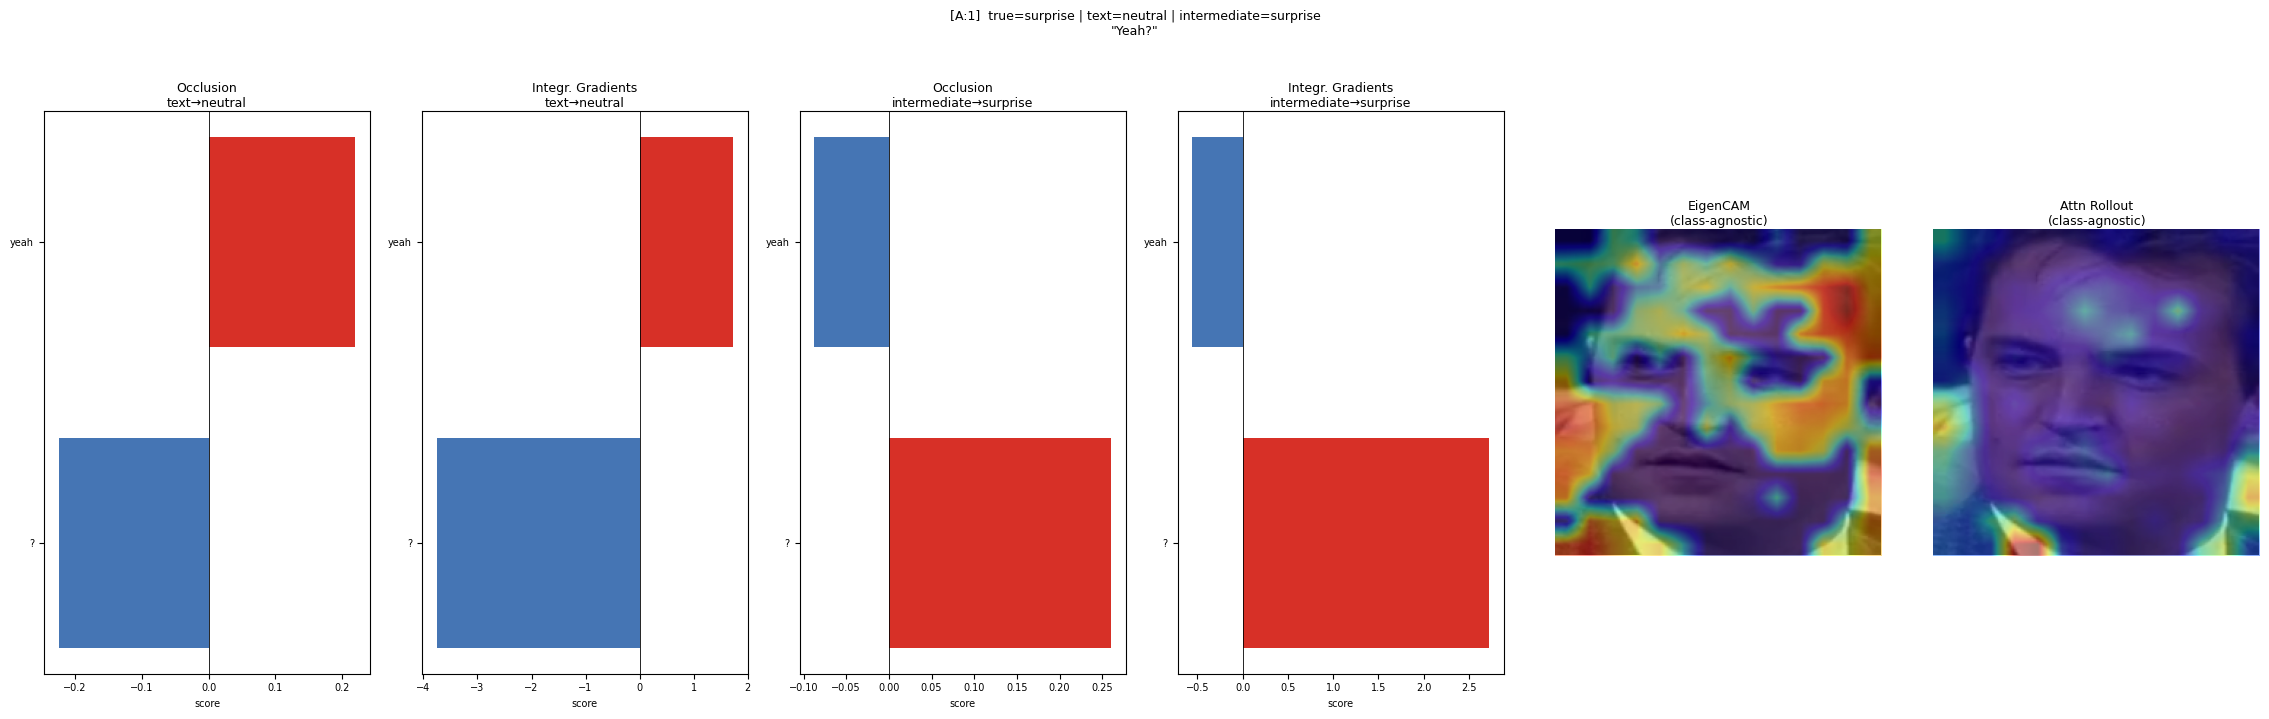


── [A:2]  d=208 u=9
   true=sadness | text=disgust | intermediate=sadness
   "Oh please, hell be with his real family, the twins and little miss new boobs."


C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:227: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:234: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.savefig(_fname, dpi=FIGURE_DPI, bbox_inches='tight')


   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\A2_d208_u9.png


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


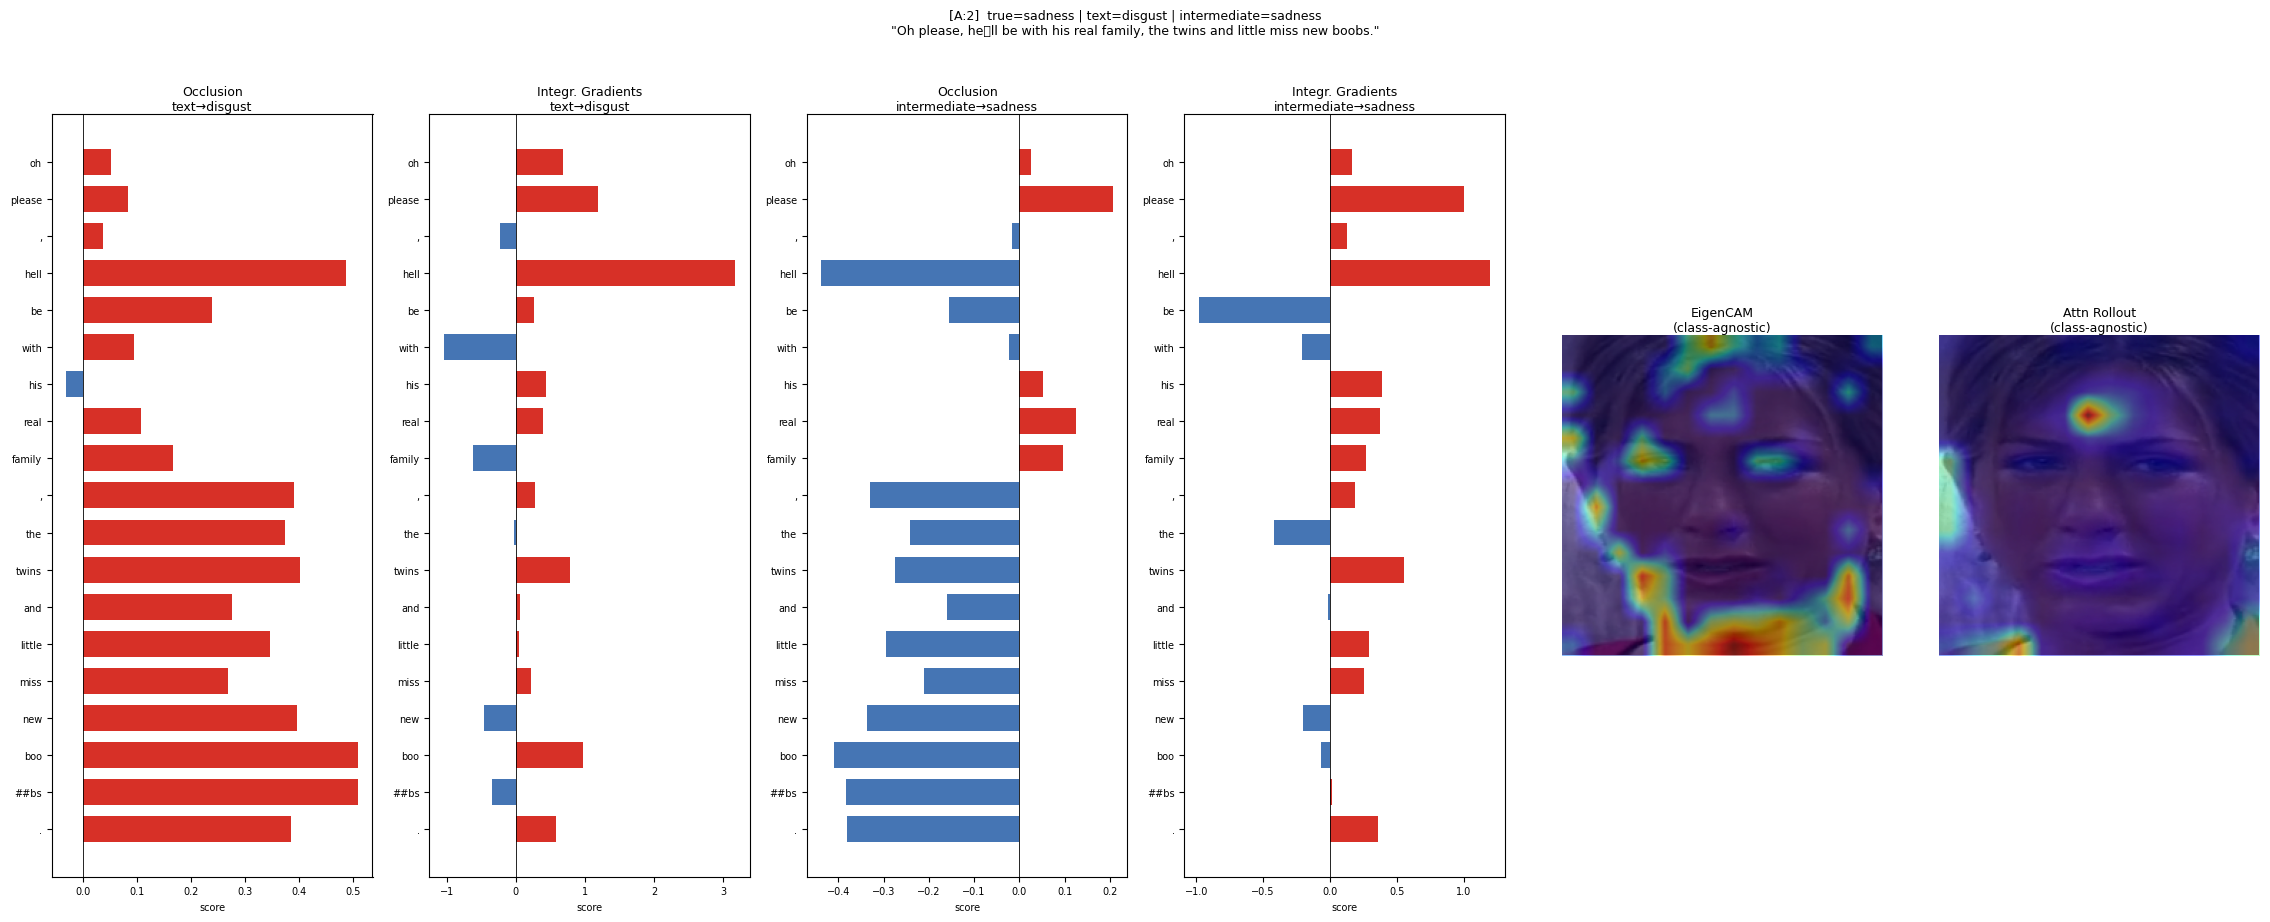


── [A:3]  d=65 u=9
   true=anger | text=happiness | intermediate=anger
   "Its Clint!"


C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:227: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:234: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.savefig(_fname, dpi=FIGURE_DPI, bbox_inches='tight')


   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\A3_d65_u9.png


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


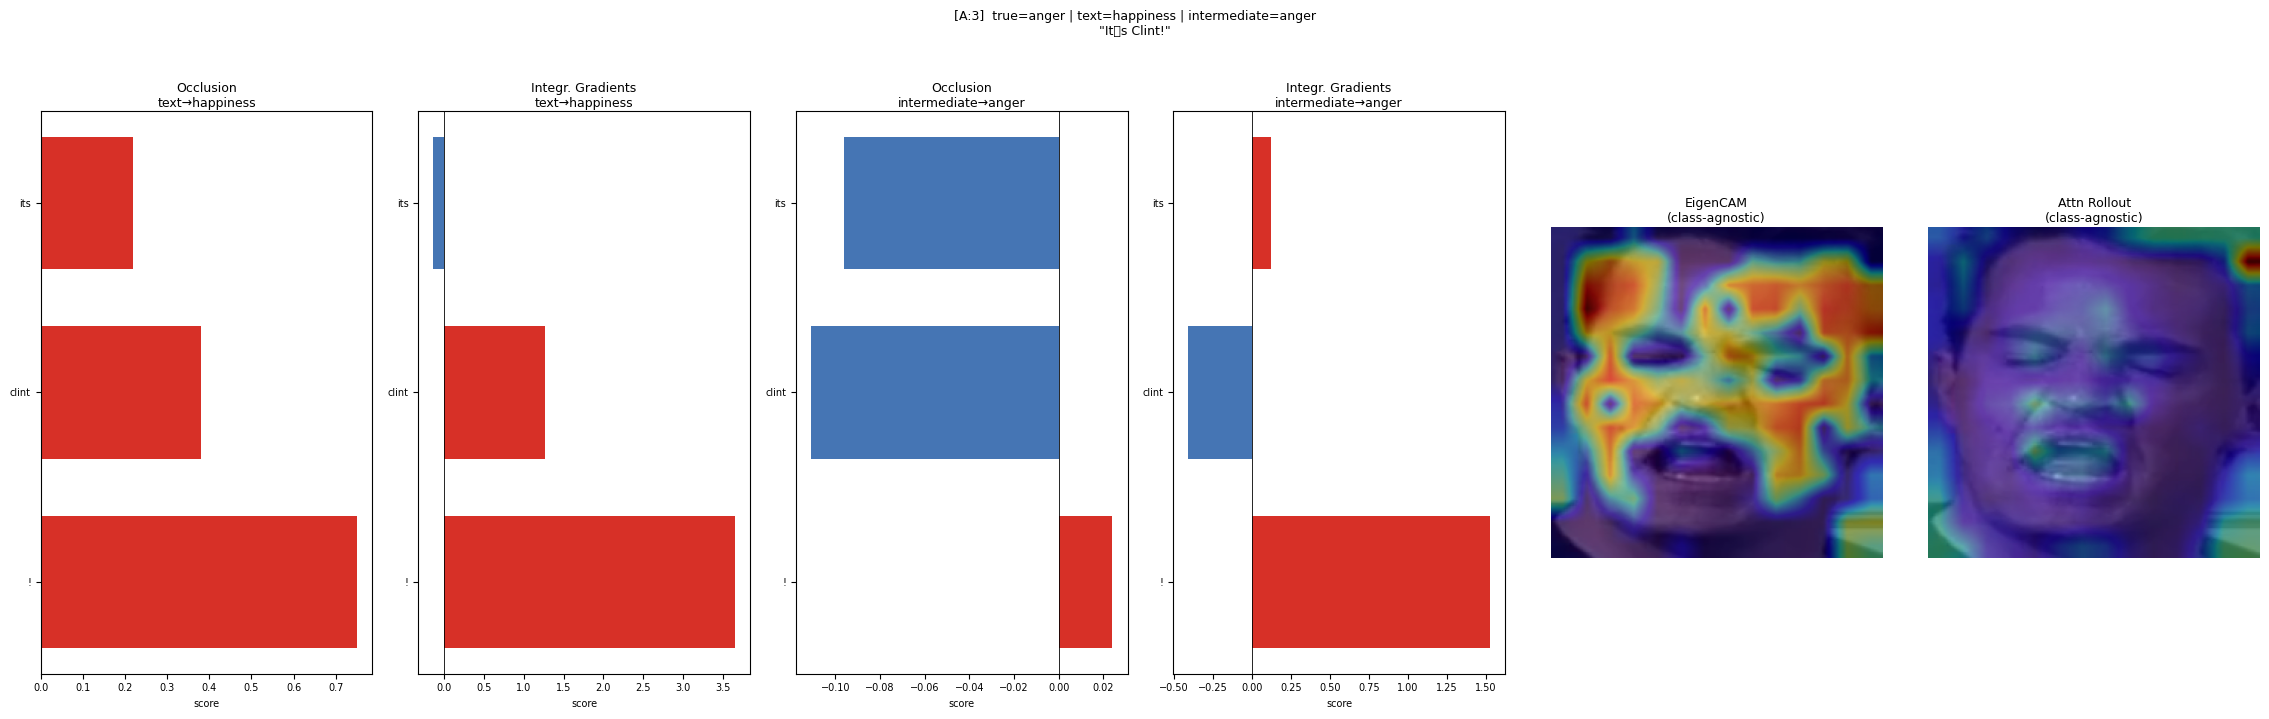


── [B:1]  d=191 u=9
   true=neutral | text=neutral | intermediate=surprise
   "Yeah?"
   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\B1_d191_u9.png


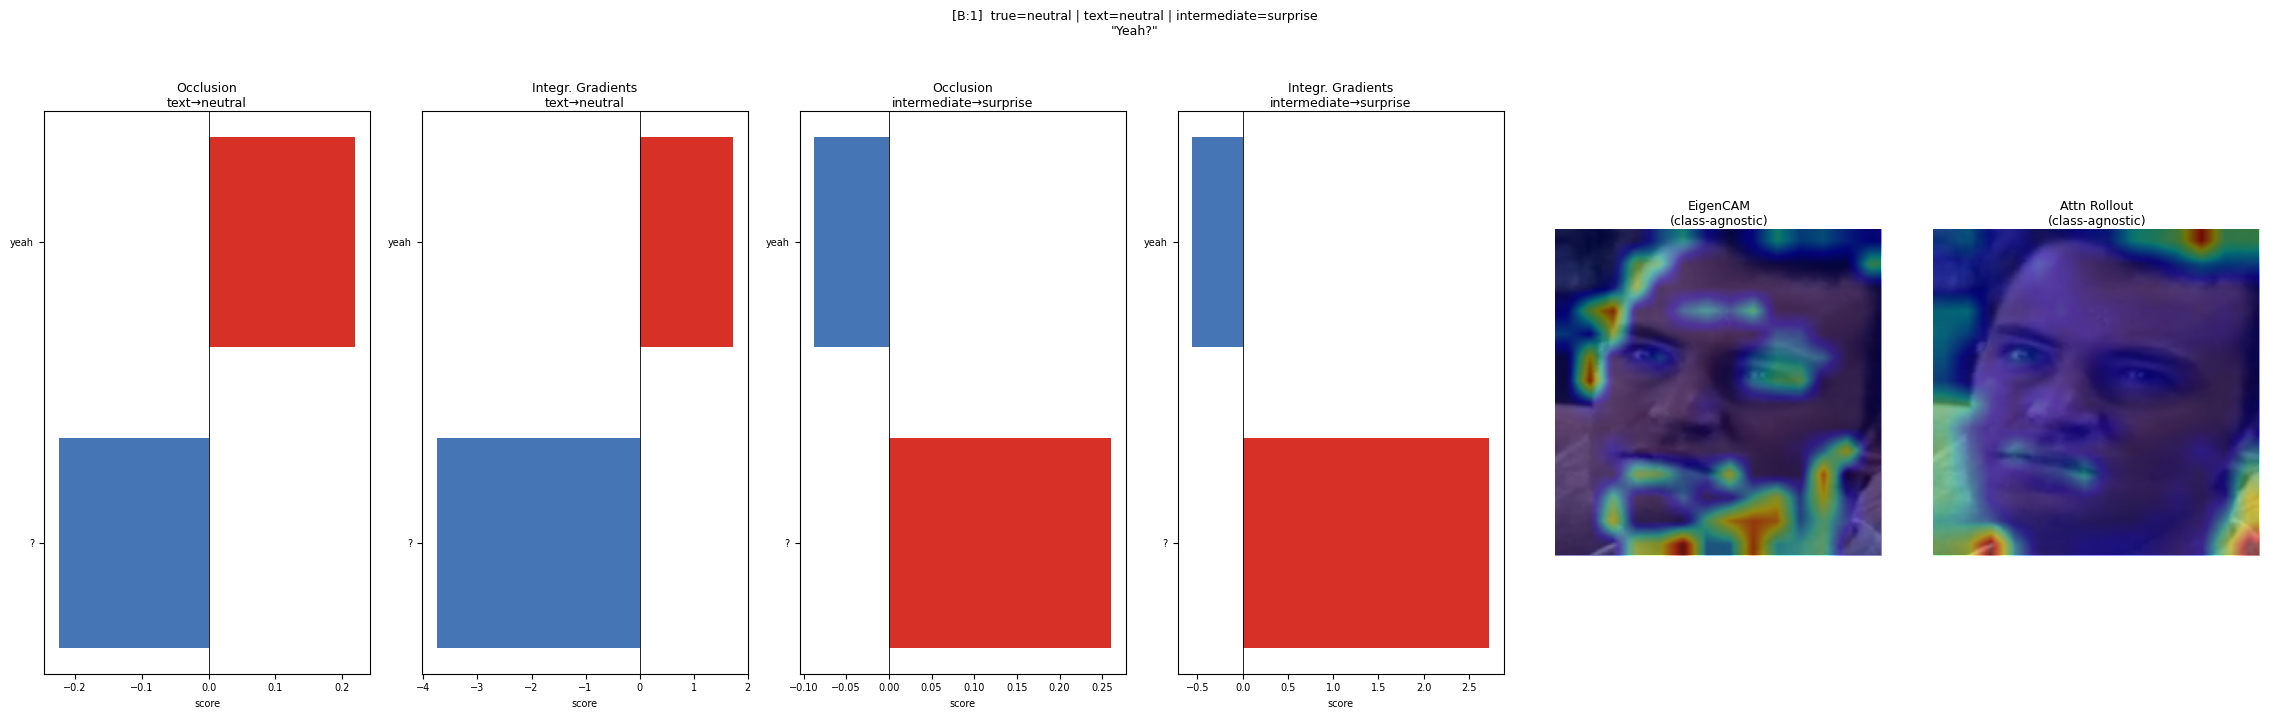


── [B:2]  d=45 u=0
   true=anger | text=anger | intermediate=sadness
   "Phoebe! Come on! Lets go!  Come on!  Why arent you dressed yet?!"


C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:227: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Andrei\AppData\Local\Temp\ipykernel_8352\131698625.py:234: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.savefig(_fname, dpi=FIGURE_DPI, bbox_inches='tight')


   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\B2_d45_u0.png


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


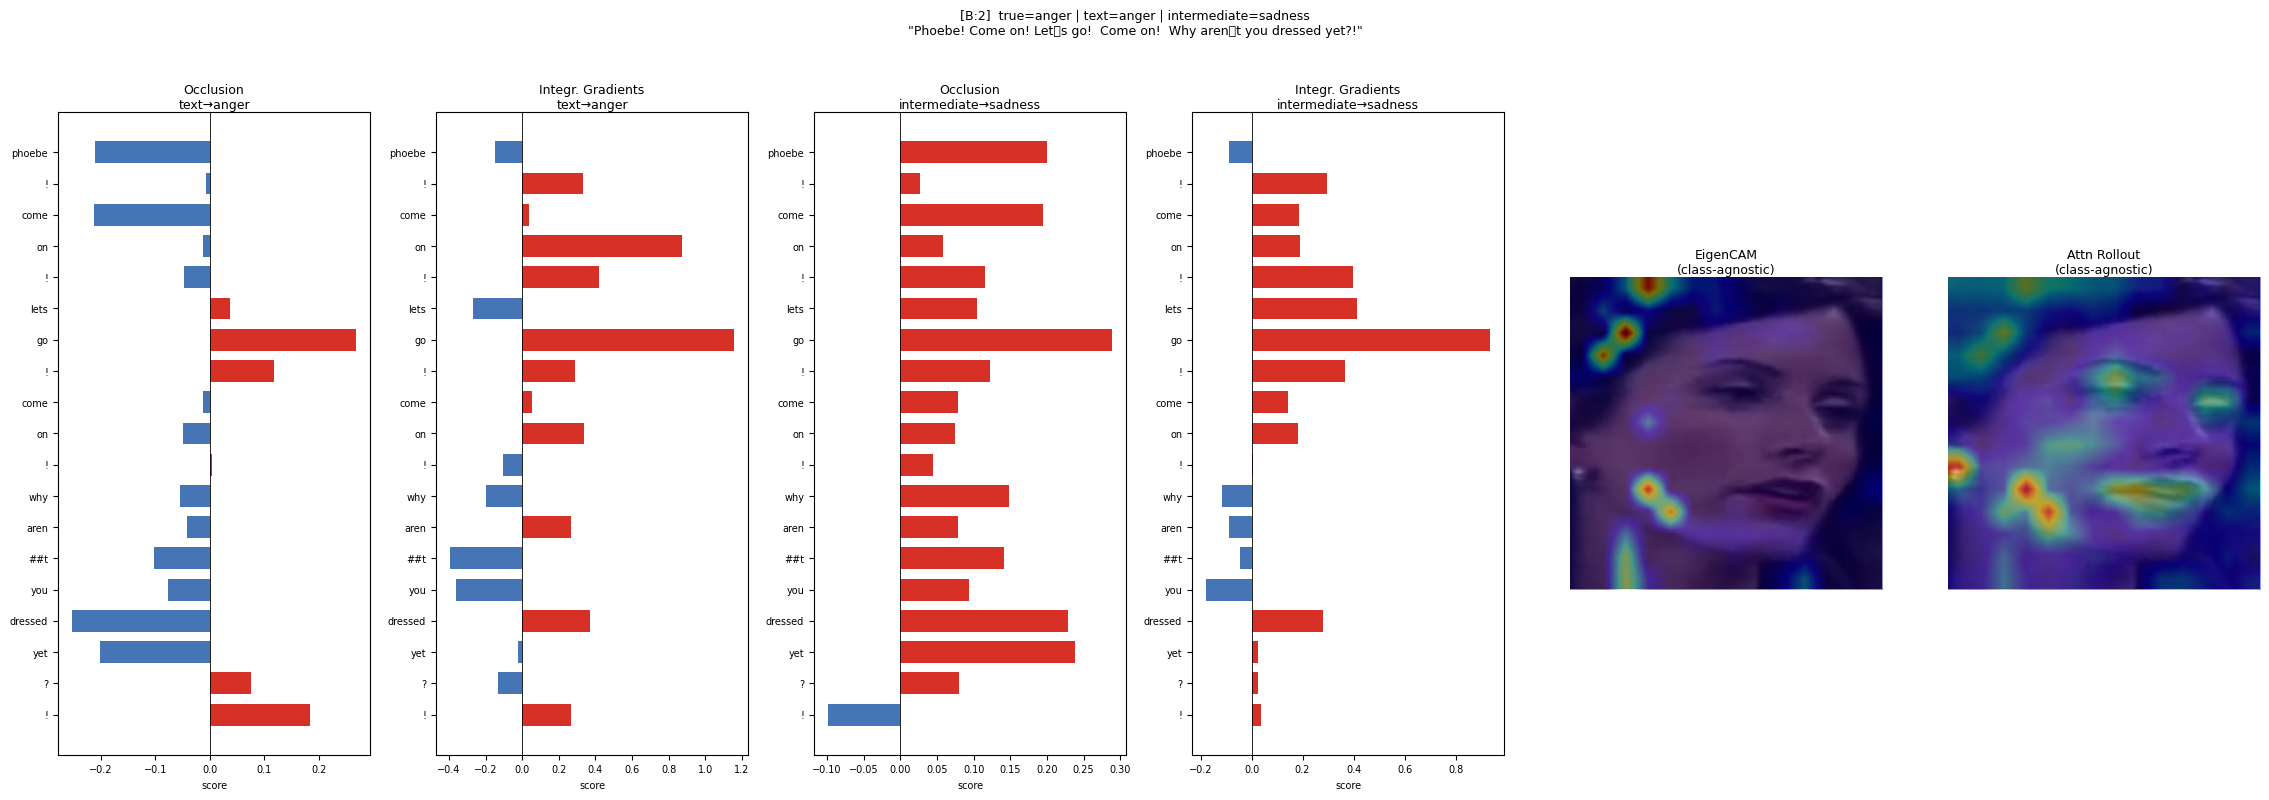


── [B:3]  d=168 u=11
   true=anger | text=anger | intermediate=fear
   "There was a ring, in a box, on my nightstand, after you left, it was gone!"
   Saved → ../results/examples/intermediate_heavy_vs_text/explainability\B3_d168_u11.png


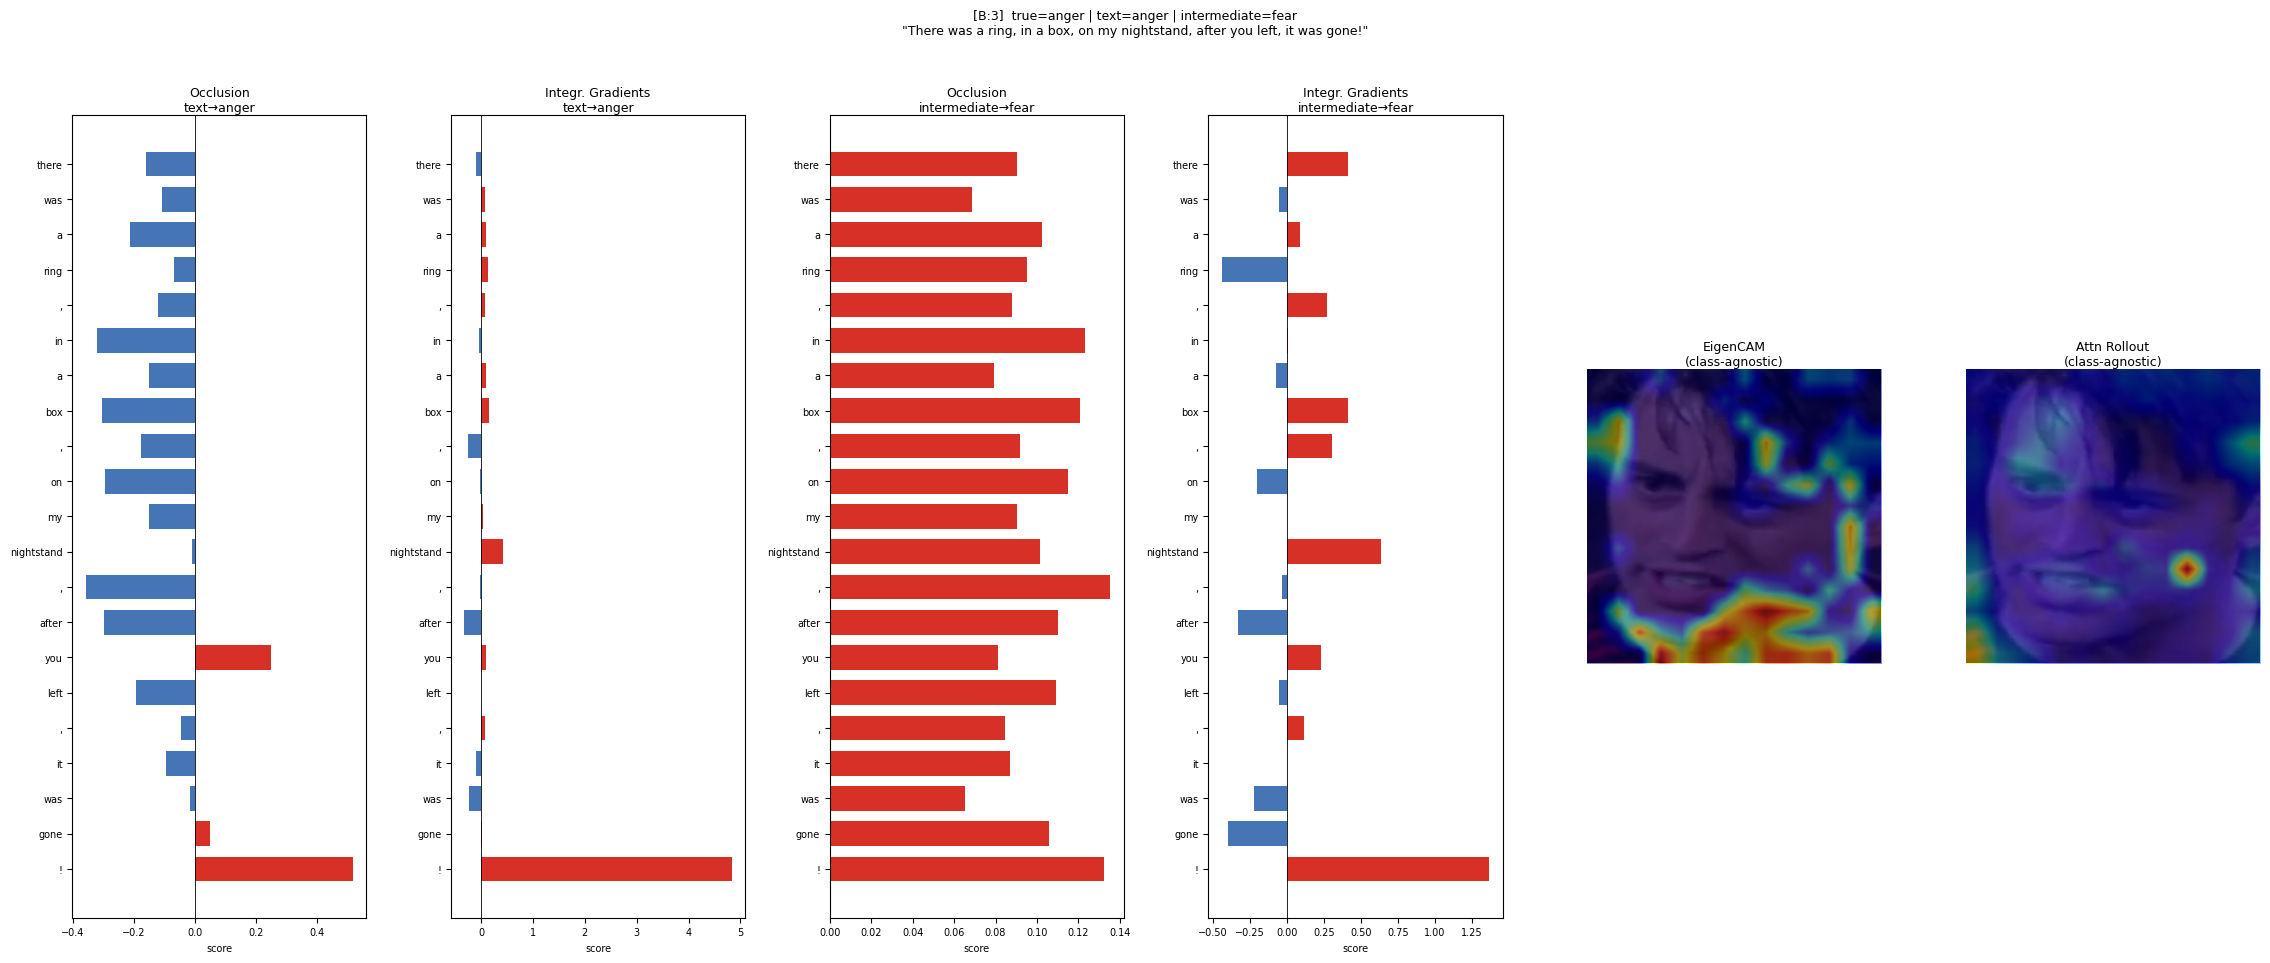


[XAI] Done.


In [151]:
# ──────────────────────────────────────────────────────────────────────────────
# 12 — Explainability for correction examples
#
# Depends on cell 11: uses idxs_A, idxs_B, keys_d, keys_u, true, uni_preds,
# fus_preds, fus_probs, _utt, UNIMODAL, MULTIMODAL, BACKBONE, DEVICE, etc.
#
# Runs TextExplainer and FaceExplainer on the full unimodal backbone models,
# attributing toward either the unimodal prediction class or the multimodal
# prediction class (or both side by side).
#
# Note on class-agnostic face methods:
#   EigenCAM and Attention Rollout do NOT depend on the target class — they
#   reflect where the backbone attends regardless of output class.  They are
#   run once per face image and shown once in the figure.
# ──────────────────────────────────────────────────────────────────────────────
import os, numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import torchvision.transforms as T
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from src.models.face_model import load_face_model
from src.explainability.text_explainability import TextExplainer
from src.explainability.face_explainability import FaceExplainer

# ── PARAMETERS ─────────────────────────────────────────────────────────────────
# EXPLAIN_TEXT — run text attribution (token occlusion / LayerIG)
EXPLAIN_TEXT = True

# EXPLAIN_FACE — run face saliency (EigenCAM / Attention Rollout)
#   Skipped automatically if no face image is found for an utterance.
EXPLAIN_FACE = True

# TEXT_METHOD — text attribution method(s)
#   'occlusion'             token occlusion only
#   'integrated_gradients'  LayerIntegratedGradients only
#   'both'                  both side by side
TEXT_METHOD = 'both'

# FACE_METHOD — face saliency method(s)
#   'gradcam'           EigenCAM (works for ViT and MobileNet)
#   'attention_rollout' Attention Rollout (ViT only; auto-falls back to gradcam for MobileNet)
#   'both'              both (attention_rollout silently skipped if MobileNet)
FACE_METHOD = 'both'

# EXPLAIN_TARGET — which prediction class to attribute text toward
#   'unimodal'   attribute toward unimodal model's predicted class
#   'multimodal' attribute toward multimodal model's predicted class
#   'both'       show both columns side by side
#   (face methods are class-agnostic and are shown once regardless of this setting)
EXPLAIN_TARGET = 'both'

# EXPLAIN_CASES — which example sets to explain
#   'A'    unimodal wrong + multimodal right
#   'B'    unimodal right + multimodal wrong
#   'both' both sets
EXPLAIN_CASES = 'both'

# MAX_EXAMPLES — maximum examples to explain per case
MAX_EXAMPLES = 3

# SAVE_FIGURES — save PNG figures to disk
SAVE_FIGURES = True

# FIGURE_DPI — output figure resolution
FIGURE_DPI = 120
# ──────────────────────────────────────────────────────────────────────────────

SKIP_TOKS = {'[CLS]', '[SEP]', '[PAD]', '<s>', '</s>', '<pad>'}
_FACE_META_CSV = '../Data/processed_meld_faces/v1/test/metadata.csv'
_FACE_IMG_ROOT = '../Data/processed_meld_faces/v1/test/images'

# ── Load full text model (backbone required by TextExplainer) ─────────────────
_txt_model_dir = os.path.join(EXP_ROOT, VERSION, txt_slug, 'model')
_txt_full = AutoModelForSequenceClassification.from_pretrained(_txt_model_dir)
_txt_tok  = AutoTokenizer.from_pretrained(_txt_model_dir)
text_explainer = TextExplainer(_txt_full, _txt_tok, DEVICE)
print(f'[XAI] Text model loaded: {txt_slug}')

# ── Load full face model (backbone required by FaceExplainer) ─────────────────
_fac_full = load_face_model(fac_slug, num_classes=7, device=DEVICE)
_fac_sd   = torch.load(fac_ckpt, map_location='cpu')
_fac_full.load_state_dict(_fac_sd)
_fac_full = _fac_full.to(DEVICE).eval()
_is_vit   = 'vit' in fac_slug
face_explainer = FaceExplainer(_fac_full, fac_slug, DEVICE)
print(f'[XAI] Face model loaded: {fac_slug}  (is_vit={_is_vit})')

# ── Face metadata ─────────────────────────────────────────────────────────────
_face_meta = pd.read_csv(_FACE_META_CSV)
_face_meta = _face_meta[_face_meta['status'] == 'ok'].copy()
_face_tf   = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def _get_face(d_id, u_id):
    """Return (pil_img, tensor[1,3,224,224]) for the best-ranked face, or (None, None)."""
    rows = _face_meta[
        (_face_meta['dialogue_id'] == d_id) & (_face_meta['utterance_id'] == u_id)
    ].sort_values('selection_rank')
    if rows.empty:
        return None, None
    img_rel  = rows.iloc[0]['image_path'].replace('\\', '/')
    img_name = os.path.basename(img_rel)
    img_path = os.path.join(_FACE_IMG_ROOT, img_name)
    if not os.path.exists(img_path):
        return None, None
    pil = Image.open(img_path).convert('RGB')
    return pil, _face_tf(pil).unsqueeze(0)

# ── Plot helpers ──────────────────────────────────────────────────────────────
def _plot_text_bars(ax, tokens, scores, title):
    keep = [(t, s) for t, s in zip(tokens, scores) if t not in SKIP_TOKS]
    if not keep:
        ax.set_title(title, fontsize=9)
        ax.text(0.5, 0.5, '(no content tokens)', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        return
    toks, vals = zip(*keep)
    colors = ['#d73027' if v > 0 else '#4575b4' for v in vals]
    ax.barh(range(len(toks)), vals, color=colors, edgecolor='none', height=0.7)
    ax.set_yticks(range(len(toks)))
    ax.set_yticklabels(toks, fontsize=7)
    ax.axvline(0, color='k', linewidth=0.6)
    ax.set_xlabel('score', fontsize=7)
    ax.set_title(title, fontsize=9, pad=3)
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=7)

def _plot_saliency(ax, pil_img, sal, title):
    lo, hi = sal.min(), sal.max()
    sal_n   = (sal - lo) / (hi - lo + 1e-8)
    arr     = np.array(pil_img.resize((224, 224)))
    ax.imshow(arr)
    ax.imshow(sal_n, cmap='jet', alpha=0.45, vmin=0, vmax=1,
              extent=[0, 224, 224, 0], interpolation='bilinear')
    ax.set_title(title, fontsize=9, pad=3)
    ax.axis('off')

# ── Determine methods to run ──────────────────────────────────────────────────
_txt_methods = []
if EXPLAIN_TEXT:
    if TEXT_METHOD in ('occlusion', 'both'):
        _txt_methods.append('occlusion')
    if TEXT_METHOD in ('integrated_gradients', 'both'):
        _txt_methods.append('integrated_gradients')

_fac_methods = []
if EXPLAIN_FACE:
    if FACE_METHOD in ('gradcam', 'both'):
        _fac_methods.append('gradcam')
    if FACE_METHOD in ('attention_rollout', 'both'):
        if _is_vit:
            _fac_methods.append('attention_rollout')
        else:
            print('[XAI] attention_rollout skipped — face model is not ViT.')

_tgt_list = []   # [(label_suffix, class_fn)] class_fn(idx) -> int
if EXPLAIN_TARGET in ('unimodal', 'both'):
    _tgt_list.append((f'{UNIMODAL}→', lambda i: int(uni_preds[i])))
if EXPLAIN_TARGET in ('multimodal', 'both'):
    _tgt_list.append((f'{MULTIMODAL}→', lambda i: int(fus_preds[i])))

# ── Per-example explainer ─────────────────────────────────────────────────────
def explain_example(idx, case_label, rank):
    d_id, u_id    = int(keys_d[idx]), int(keys_u[idx])
    utt           = _utt.get((d_id, u_id), '[utterance not found]')
    true_emo      = ID2EMO[true[idx]]
    uni_emo       = ID2EMO[uni_preds[idx]]
    fus_emo       = ID2EMO[fus_preds[idx]]

    print(f'\n── [{case_label}:{rank}]  d={d_id} u={u_id}')
    print(f'   true={true_emo} | {UNIMODAL}={uni_emo} | {MULTIMODAL}={fus_emo}')
    print(f'   "{utt}"')

    pil_img, face_tensor = _get_face(d_id, u_id)
    has_face = pil_img is not None
    if EXPLAIN_FACE and not has_face:
        print('   (no face image → face XAI skipped)')

    # Panel layout: [text methods × targets | face methods (once)]
    n_txt = len(_txt_methods) * len(_tgt_list) if _txt_methods else 0
    n_fac = len(_fac_methods) if (has_face and _fac_methods) else 0
    n_cols = n_txt + n_fac
    if n_cols == 0:
        print('   (nothing to explain for this example)')
        return

    fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, max(7, len(utt.split()) * 0.4 + 3)))
    if n_cols == 1:
        axes = [axes]

    ax_i = 0

    # ── Text panels ───────────────────────────────────────────────────────────
    for tgt_label, tgt_fn in _tgt_list:
        tgt_class = tgt_fn(idx)
        tgt_emo   = ID2EMO[tgt_class]
        for tm in _txt_methods:
            ax = axes[ax_i]; ax_i += 1
            if tm == 'occlusion':
                toks, scores, _ = text_explainer.token_occlusion(utt, target_class=tgt_class)
                _plot_text_bars(ax, toks, scores, f'Occlusion\n{tgt_label}{tgt_emo}')
            else:
                toks, scores, _ = text_explainer.integrated_gradients(utt, target_class=tgt_class)
                _plot_text_bars(ax, toks, scores, f'Integr. Gradients\n{tgt_label}{tgt_emo}')

    # ── Face panels (class-agnostic — run once each) ──────────────────────────
    if has_face:
        for fm in _fac_methods:
            ax = axes[ax_i]; ax_i += 1
            if fm == 'gradcam':
                sal, _ = face_explainer.grad_cam(face_tensor)   # class-agnostic
                _plot_saliency(ax, pil_img, sal, 'EigenCAM\n(class-agnostic)')
            else:  # attention_rollout
                sal = face_explainer.attention_rollout(face_tensor)
                _plot_saliency(ax, pil_img, sal, 'Attn Rollout\n(class-agnostic)')

    suptitle = (
        f'[{case_label}:{rank}]  true={true_emo} | '
        f'{UNIMODAL}={uni_emo} | {MULTIMODAL}={fus_emo}\n'
        f'"{utt[:100]}{"…" if len(utt) > 100 else ""}"'
    )
    fig.suptitle(suptitle, fontsize=9, y=1.02)
    fig.tight_layout()

    if SAVE_FIGURES:
        _xai_dir = (f'../results/examples/{MULTIMODAL}_{BACKBONE}_vs_{UNIMODAL}'
                    f'/explainability')
        os.makedirs(_xai_dir, exist_ok=True)
        _fname = os.path.join(_xai_dir, f'{case_label}{rank}_d{d_id}_u{u_id}.png')
        fig.savefig(_fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f'   Saved → {_fname}')

    plt.show()
    plt.close(fig)

# ── Collect examples and explain ──────────────────────────────────────────────
_cases = []

if EXPLAIN_CASES in ('A', 'both'):
    _shown, _cnt = set(), 0
    for _idx in idxs_A:
        if _cnt >= MAX_EXAMPLES:
            break
        _emo = ID2EMO[true[_idx]]
        if _emo in _shown:
            continue
        _shown.add(_emo); _cnt += 1
        _cases.append(('A', _cnt, _idx))

if EXPLAIN_CASES in ('B', 'both'):
    _sorted_B = idxs_B[fus_probs[idxs_B].max(axis=1).argsort()[::-1]]
    for _rank_B, _idx in enumerate(_sorted_B[:MAX_EXAMPLES], 1):
        _cases.append(('B', _rank_B, _idx))

print(f'[XAI] Explaining {len(_cases)} example(s)')
print(f'      text={EXPLAIN_TEXT}/{TEXT_METHOD}  face={EXPLAIN_FACE}/{FACE_METHOD}')
print(f'      target={EXPLAIN_TARGET}  cases={EXPLAIN_CASES}')

for _case_label, _rank, _idx in _cases:
    explain_example(_idx, _case_label, _rank)

print('\n[XAI] Done.')


---
## 13 — Full Test-Set Predictions Export

Builds a master table with the ground-truth label and predictions from every trained model (6 unimodal + 4 fusion variants) for all test utterances, and saves it to `results/full_test_predictions.xlsx`.

In [152]:
# ──────────────────────────────────────────────────────────────────────────────
# 13 — Export full per-utterance predictions table (Excel)
#
# Builds one master table covering ALL test utterances (2610 rows) with the
# ground-truth label and predictions from every model:
#   - 6 unimodal models  (heavy: BERT, wav2vec2, ViT-B/16 |
#                          light: DistilBERT, DistilHuBERT, MobileNetV3-Small)
#   - 2 late-weighted fusion models (heavy / light)
#   - 2 intermediate (ProjectionFusionMLP) fusion models (heavy / light)
#   - 2 gated fusion models (light->GatedFusionLight, heavy->GatedFusionHeavy)
#
# Face-dependent columns (vit_pred, mobilenet_pred, and any fusion column that
# uses the face modality) are left blank (NaN) for the ~5% of utterances with
# no detected face crop.
#
# Saved to  results/full_test_predictions.xlsx
# ──────────────────────────────────────────────────────────────────────────────
import os, torch, numpy as np, pandas as pd
from safetensors import safe_open
from src.evaluation.intermediate_fusion import ProjectionFusionMLP
from src.evaluation.gated_fusion import GatedFusionLight, GatedFusionHeavy

EMOTIONS = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
ID2EMO   = {i: e for i, e in enumerate(EMOTIONS)}
TEST_CSV = '../Data/MELD.Raw/test_sent_emo.csv'
_GATED_B = '../experiments/fusion/gated'


def _npz(cache_root, name):
    d = np.load(os.path.join(cache_root, f'{name}_test.npz'))
    return d['embeddings'], d['labels'].astype(int), d['d_ids'].astype(int), d['u_ids'].astype(int)


def _hf_head(run_dir_rel, weight_key='classifier.weight', bias_key='classifier.bias'):
    sf = os.path.join(run_dir_rel, 'model', 'model.safetensors')
    with safe_open(sf, framework='pt', device='cpu') as f:
        return f.get_tensor(weight_key), f.get_tensor(bias_key)


def _pt_head(ckpt_path, weight_key, bias_key):
    sd = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    return sd[weight_key], sd[bias_key]


def _logits(embs, W, b):
    return torch.tensor(embs, dtype=torch.float32) @ W.T + b


def _preds(logits):
    return logits.argmax(dim=-1).numpy()


def _sel(embs, dids, uids, keys):
    m = {(int(d), int(u)): i for i, (d, u) in enumerate(zip(dids, uids))}
    return embs[[m[k] for k in keys]]


def _to_map(keys, arr):
    return {k: int(v) for k, v in zip(keys, arr)}


# ── Test utterance text ─────────────────────────────────────────────────────
test_csv = pd.read_csv(TEST_CSV)
_utt = {(int(r.Dialogue_ID), int(r.Utterance_ID)): str(r.Utterance) for r in test_csv.itertuples()}

results = {}

for backbone in ['heavy', 'light']:
    cache_root = os.path.join(INTER_FUSION_ROOT, backbone, 'cache')
    cfg = load_json(os.path.join(INTER_FUSION_ROOT, backbone, 'config.json'))
    emb_dims = cfg['emb_dims']

    te, tl, td, tu = _npz(cache_root, 'text')
    ae, al, ad, au = _npz(cache_root, 'audio')
    fe, fl, fd, fu = _npz(cache_root, 'face')

    base_keys = sorted(set(zip(td.tolist(), tu.tolist())) & set(zip(ad.tolist(), au.tolist())))
    fac_key_set = set(zip(fd.tolist(), fu.tolist()))
    common_keys = sorted(set(base_keys) & fac_key_set)

    txt_e = _sel(te, td, tu, base_keys)
    aud_e = _sel(ae, ad, au, base_keys)
    lbl_m = {(int(d), int(u)): int(l) for d, u, l in zip(td, tu, tl)}
    true = np.array([lbl_m[k] for k in base_keys])

    # ── Unimodal heads ───────────────────────────────────────────────────────
    txt_slug = os.path.basename(cfg['text_run_dir'].replace('\\', '/'))
    W_t, b_t = _hf_head(os.path.join(EXP_ROOT, VERSION, txt_slug))
    txt_logits = _logits(txt_e, W_t, b_t)

    aud_slug = os.path.basename(cfg['audio_run_dir'].replace('\\', '/'))
    W_a, b_a = _hf_head(os.path.join(EXP_ROOT_AUDIO, VERSION, aud_slug))
    aud_logits = _logits(aud_e, W_a, b_a)

    fac_slug = os.path.basename(cfg['face_run_dir'].replace('\\', '/'))
    fac_ckpt = os.path.join(EXP_ROOT_FACE, VERSION, fac_slug, 'model', 'best_model.pt')
    if 'vit' in fac_slug:
        W_f, b_f = _pt_head(fac_ckpt, 'heads.head.1.weight', 'heads.head.1.bias')
    else:
        W_f, b_f = _pt_head(fac_ckpt, 'classifier.3.weight', 'classifier.3.bias')

    fac_e_common = _sel(fe, fd, fu, common_keys)
    fac_logits_common = _logits(fac_e_common, W_f, b_f)

    # ── Fusion models (need all 3 modalities -> common_keys subset) ─────────
    txt_e_c = _sel(te, td, tu, common_keys)
    aud_e_c = _sel(ae, ad, au, common_keys)
    txt_logits_c = _logits(txt_e_c, W_t, b_t)
    aud_logits_c = _logits(aud_e_c, W_a, b_a)
    feats_c = {'text': txt_e_c, 'audio': aud_e_c, 'face': fac_e_common}
    feats_t = {m: torch.tensor(feats_c[m], dtype=torch.float32) for m in feats_c}

    # late weighted
    w = load_json(os.path.join(LATE_FUSION_ROOT, backbone, 'weights.json'))
    late_logits = w['text'] * txt_logits_c + w['audio'] * aud_logits_c + w['face'] * fac_logits_common

    # intermediate (ProjectionFusionMLP)
    mlp = ProjectionFusionMLP(
        in_dims=emb_dims,
        d_proj=cfg.get('mlp_d_proj', 128),
        d_hidden=cfg.get('mlp_d_hidden', 256),
        num_classes=7, dropout=0.0, modality_dropout=0.0,
    )
    mlp.load_state_dict(torch.load(
        os.path.join(INTER_FUSION_ROOT, backbone, 'fusion_mlp.pt'),
        map_location='cpu', weights_only=True))
    mlp.eval()
    with torch.no_grad():
        mlp_logits = mlp(feats_t)

    # gated fusion — only the requested combo per backbone
    #   light backbone -> GatedFusionLight  (gated_light_light_pred)
    #   heavy backbone -> GatedFusionHeavy  (gated_heavy_heavy_pred)
    if backbone == 'light':
        cfg_g = load_json(os.path.join(_GATED_B, 'light', VERSION, 'light', 'config.json'))
        ckpt_g = os.path.join(_GATED_B, 'light', VERSION, 'light', 'gated_fusion.pt')
        model_g = GatedFusionLight(
            in_dims=emb_dims, d_proj=cfg_g.get('d_proj', 128),
            d_hidden=cfg_g.get('d_hidden', 128), num_classes=7, dropout=0.0,
        )
    else:
        cfg_g = load_json(os.path.join(_GATED_B, 'heavy', VERSION, 'heavy', 'config.json'))
        ckpt_g = os.path.join(_GATED_B, 'heavy', VERSION, 'heavy', 'gated_fusion.pt')
        model_g = GatedFusionHeavy(
            in_dims=emb_dims, d_model=cfg_g.get('d_model', 256),
            nhead=cfg_g.get('nhead', 4), num_layers=cfg_g.get('num_layers', 2),
            d_ff=cfg_g.get('d_ff', 512), d_hidden=cfg_g.get('d_hidden', 256),
            num_classes=7, dropout=0.0,
        )
    model_g.load_state_dict(torch.load(ckpt_g, map_location='cpu', weights_only=True))
    model_g.eval()
    with torch.no_grad():
        gated_logits = model_g(feats_t)

    results[backbone] = dict(
        base_keys=base_keys, common_keys=common_keys, true=true,
        txt_preds=_preds(txt_logits), aud_preds=_preds(aud_logits),
        fac_preds=_preds(fac_logits_common),
        late_preds=_preds(late_logits), mlp_preds=_preds(mlp_logits),
        gated_preds=_preds(gated_logits),
    )
    print(f'{backbone}: total={len(base_keys)}  with-face={len(common_keys)}')

# ── Assemble master table ────────────────────────────────────────────────────
heavy, light = results['heavy'], results['light']
assert set(heavy['base_keys']) == set(light['base_keys']), 'heavy/light test sets differ'
master_keys = heavy['base_keys']

m_true       = _to_map(heavy['base_keys'], heavy['true'])
m_bert       = _to_map(heavy['base_keys'], heavy['txt_preds'])
m_distilbert = _to_map(light['base_keys'], light['txt_preds'])
m_wav2vec2   = _to_map(heavy['base_keys'], heavy['aud_preds'])
m_distilhub  = _to_map(light['base_keys'], light['aud_preds'])
m_vit        = _to_map(heavy['common_keys'], heavy['fac_preds'])
m_mobilenet  = _to_map(light['common_keys'], light['fac_preds'])
m_late_h     = _to_map(heavy['common_keys'], heavy['late_preds'])
m_late_l     = _to_map(light['common_keys'], light['late_preds'])
m_mlp_h      = _to_map(heavy['common_keys'], heavy['mlp_preds'])
m_mlp_l      = _to_map(light['common_keys'], light['mlp_preds'])
m_gated_ll   = _to_map(light['common_keys'], light['gated_preds'])
m_gated_hh   = _to_map(heavy['common_keys'], heavy['gated_preds'])


def _emo(m, k):
    return ID2EMO[m[k]] if k in m else np.nan


rows = []
for k in master_keys:
    d, u = k
    rows.append({
        'dialogue_id': d,
        'utterance_id': u,
        'utterance': _utt.get(k, ''),
        'true_label': ID2EMO[m_true[k]],
        'bert_pred': _emo(m_bert, k),
        'distilbert_pred': _emo(m_distilbert, k),
        'wav2vec2_pred': _emo(m_wav2vec2, k),
        'distilhubert_pred': _emo(m_distilhub, k),
        'vit_pred': _emo(m_vit, k),
        'mobilenet_pred': _emo(m_mobilenet, k),
        'late_weighted_heavy_pred': _emo(m_late_h, k),
        'late_weighted_light_pred': _emo(m_late_l, k),
        'mlp_heavy_pred': _emo(m_mlp_h, k),
        'mlp_light_pred': _emo(m_mlp_l, k),
        'gated_light_light_pred': _emo(m_gated_ll, k),
        'gated_heavy_heavy_pred': _emo(m_gated_hh, k),
    })

results_df = pd.DataFrame(rows)
print(f'Master table: {len(results_df)} rows, {results_df.shape[1]} columns')
display(results_df.head())

# ── Save to Excel ─────────────────────────────────────────────────────────────
out_dir = '../results'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'full_test_predictions.xlsx')
results_df.to_excel(out_path, index=False)
print(f'Saved -> {os.path.abspath(out_path)}')


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


heavy: total=2610  with-face=2481
light: total=2610  with-face=2481
Master table: 2610 rows, 16 columns


,dialogue_id,utterance_id,utterance,true_label,bert_pred,distilbert_pred,wav2vec2_pred,distilhubert_pred,vit_pred,mobilenet_pred,late_weighted_heavy_pred,late_weighted_light_pred,mlp_heavy_pred,mlp_light_pred,gated_light_light_pred,gated_heavy_heavy_pred
0,0,0,Why do all youre coffee mugs have numbers on ...,surprise,surprise,neutral,neutral,neutral,sadness,sadness,surprise,neutral,surprise,neutral,neutral,neutral
1,0,1,Oh. Thats so Monica can keep track. That way ...,anger,neutral,neutral,neutral,neutral,surprise,disgust,neutral,neutral,neutral,neutral,neutral,neutral
2,0,2,Y'know what?,neutral,neutral,neutral,neutral,neutral,sadness,sadness,neutral,neutral,neutral,neutral,neutral,neutral
3,1,0,"Come on, Lydia, you can do it.",neutral,neutral,neutral,surprise,anger,anger,anger,neutral,neutral,neutral,neutral,neutral,neutral
4,1,1,Push!,happiness,anger,anger,surprise,surprise,anger,anger,anger,anger,anger,anger,anger,anger


Saved -> e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\results\full_test_predictions.xlsx


---
## 14 — Confusion Matrices: Light vs Heavy

Two figures: a 3x2 grid of unimodal confusion matrices (Text / Audio / Face rows, Light / Heavy columns) and a 1x2 figure comparing the late-weighted fusion confusion matrices for the Light and Heavy backbones.

Salvat -> e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\results\confusion_matrices\unimodal_grid_light_vs_heavy.png


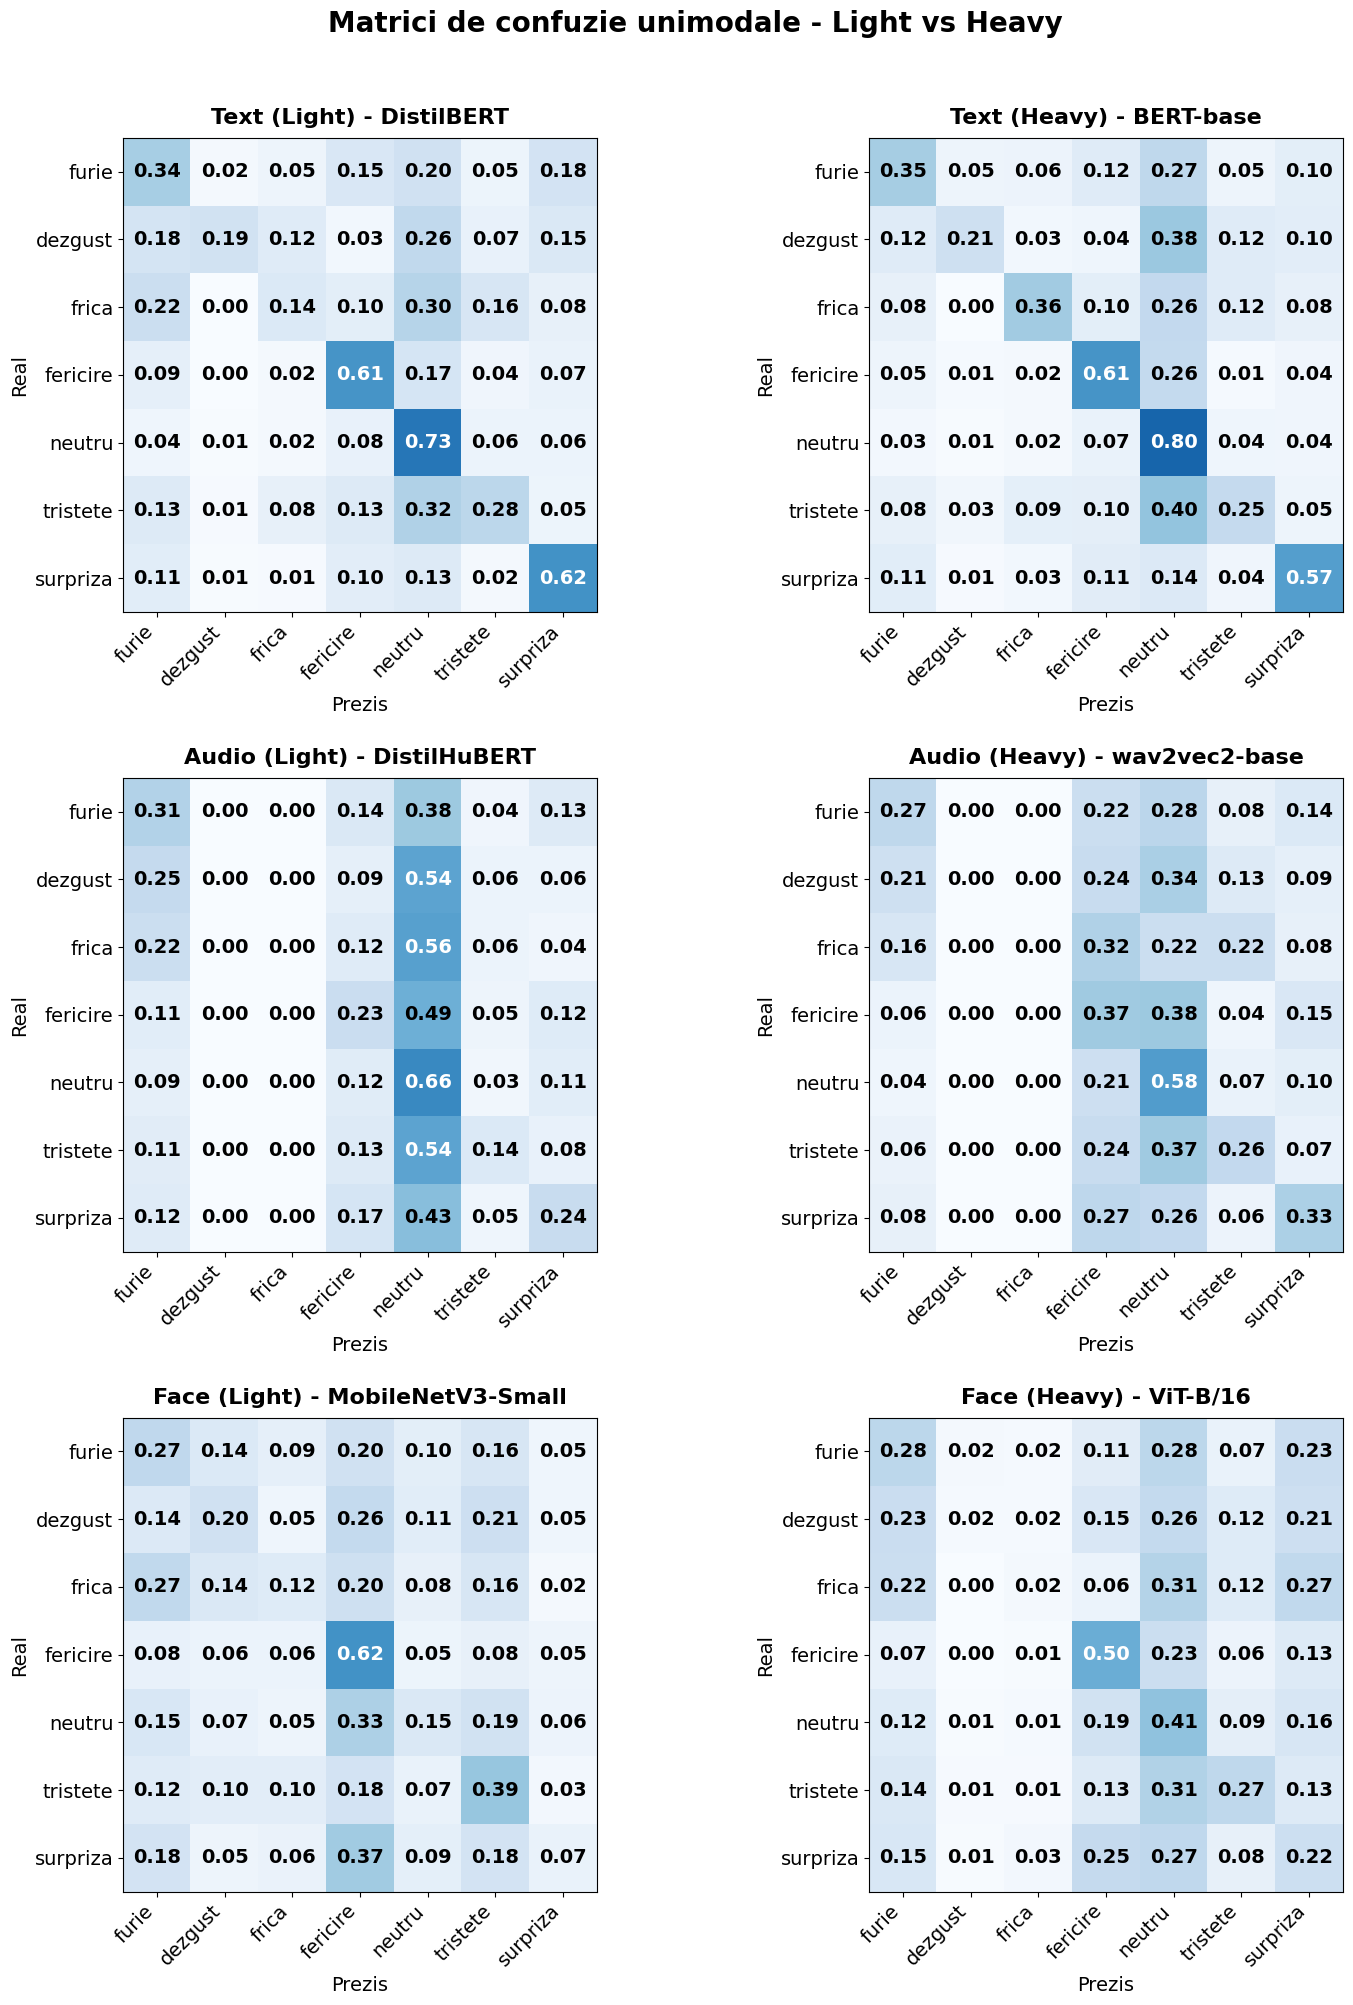

Salvat -> e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\results\confusion_matrices\late_weighted_light_vs_heavy.png


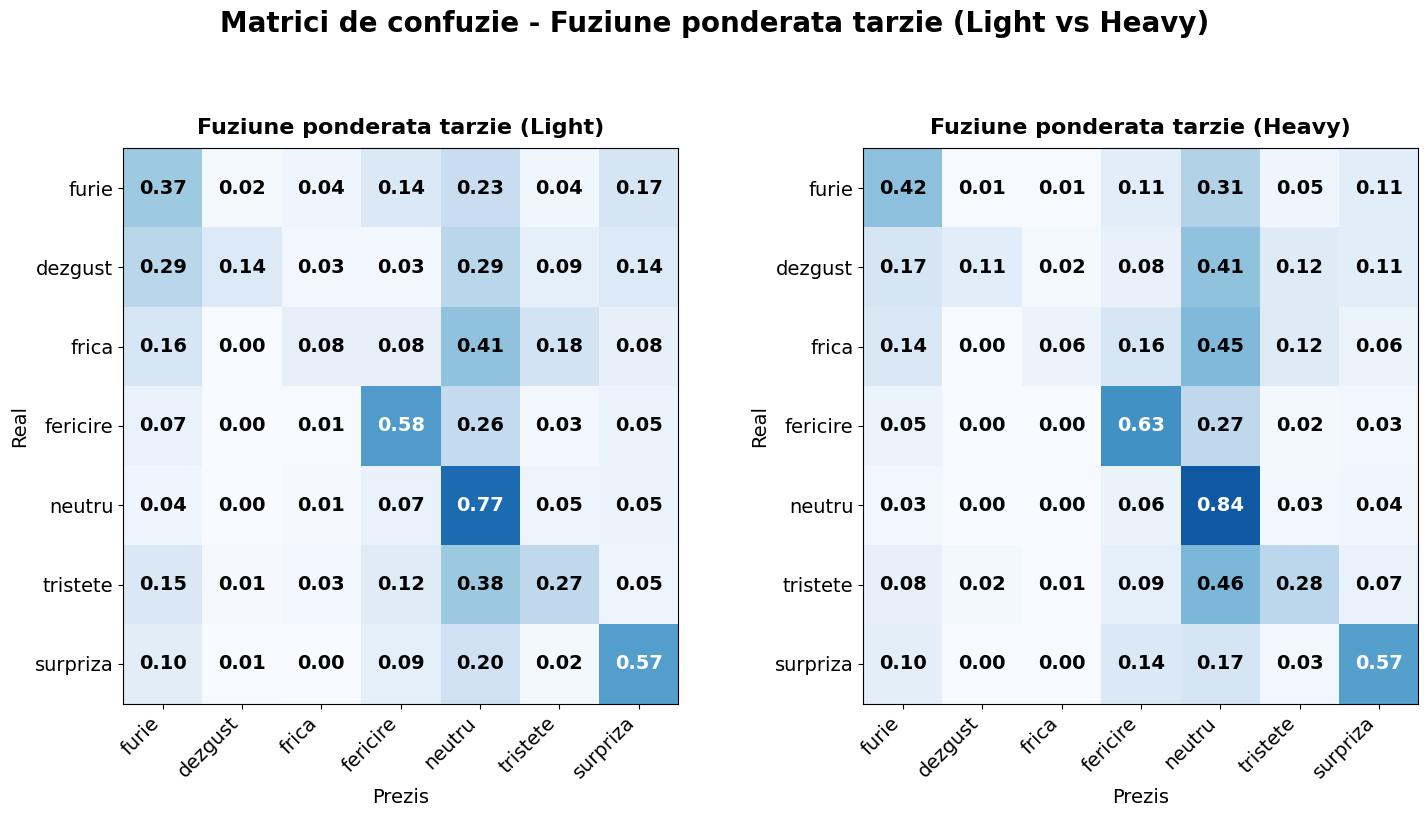

In [153]:
# --------------------------------------------------------------------------------
# 14 - Confusion matrices: Light vs Heavy (unimodal grid + late-fusion pair)
#
# Figura 1: 3 randuri (Text / Audio / Face) x 2 coloane (Light / Heavy) - matrici
#           de confuzie unimodale, normalizate pe clasa reala (recall), font mare,
#           aranjate compact pentru citire usoara.
# Figura 2: 1 rand x 2 coloane - matrici de confuzie pentru fuziunea ponderata
#           tarzie, Light vs Heavy.
#
# Foloseste `results_df` produs de celula "Full Test-Set Predictions Export".
# Etichetele sunt afisate in limba romana.
# --------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

EMOTIONS = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
EMOTII_RO = {
    'anger': 'furie', 'disgust': 'dezgust', 'fear': 'frica', 'happiness': 'fericire',
    'neutral': 'neutru', 'sadness': 'tristete', 'surprise': 'surpriza',
}
LABELS_RO = [EMOTII_RO[e] for e in EMOTIONS]
CM_OUT = '../results/confusion_matrices'
os.makedirs(CM_OUT, exist_ok=True)

if 'results_df' not in globals():
    results_df = pd.read_excel('../results/full_test_predictions.xlsx')


def _plot_cm(ax, y_true, y_pred, title, fontsize=15):
    cm = confusion_matrix(y_true, y_pred, labels=EMOTIONS, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=fontsize + 2, fontweight='bold', pad=10)
    ax.set_xticks(range(len(EMOTIONS)))
    ax.set_yticks(range(len(EMOTIONS)))
    ax.set_xticklabels(LABELS_RO, rotation=45, ha='right', fontsize=fontsize)
    ax.set_yticklabels(LABELS_RO, fontsize=fontsize)
    ax.set_xlabel('Prezis', fontsize=fontsize)
    ax.set_ylabel('Real', fontsize=fontsize)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=fontsize, color=color, fontweight='bold')
    return im


# -- Figura 1: grid unimodal - 3 randuri (Text/Audio/Face) x 2 coloane (Light/Heavy) --
unimodal_pairs = [
    ('Text',  'distilbert_pred', 'bert_pred'),
    ('Audio', 'distilhubert_pred', 'wav2vec2_pred'),
    ('Face',  'mobilenet_pred',  'vit_pred'),
]
col_titles = {'light': 'Light', 'heavy': 'Heavy'}
model_names = {
    'distilbert_pred': 'DistilBERT', 'bert_pred': 'BERT-base',
    'distilhubert_pred': 'DistilHuBERT', 'wav2vec2_pred': 'wav2vec2-base',
    'mobilenet_pred': 'MobileNetV3-Small', 'vit_pred': 'ViT-B/16',
}

fig1, axes1 = plt.subplots(3, 2, figsize=(15, 20))
fig1.suptitle('Matrici de confuzie unimodale - Light vs Heavy',
               fontsize=20, fontweight='bold', y=1.0)

for row, (modality, light_col, heavy_col) in enumerate(unimodal_pairs):
    for col, pred_col in enumerate([light_col, heavy_col]):
        ax = axes1[row, col]
        sub = results_df.dropna(subset=[pred_col])
        title = f'{modality} ({col_titles["light" if col == 0 else "heavy"]}) - {model_names[pred_col]}'
        _plot_cm(ax, sub['true_label'], sub[pred_col], title, fontsize=14)

fig1.tight_layout(rect=[0, 0, 1, 0.98])
fig1.subplots_adjust(wspace=0.15, hspace=0.35)
fig1_path = os.path.join(CM_OUT, 'unimodal_grid_light_vs_heavy.png')
fig1.savefig(fig1_path, dpi=150, bbox_inches='tight')
print(f'Salvat -> {os.path.abspath(fig1_path)}')
plt.show()


# -- Figura 2: fuziune ponderata tarzie - Light vs Heavy --
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 7.5))
fig2.suptitle('Matrici de confuzie - Fuziune ponderata tarzie (Light vs Heavy)',
               fontsize=20, fontweight='bold', y=1.05)

for col, (pred_col, label) in enumerate([
    ('late_weighted_light_pred', 'Fuziune ponderata tarzie (Light)'),
    ('late_weighted_heavy_pred', 'Fuziune ponderata tarzie (Heavy)'),
]):
    ax = axes2[col]
    sub = results_df.dropna(subset=[pred_col])
    _plot_cm(ax, sub['true_label'], sub[pred_col], label, fontsize=14)

fig2.tight_layout(rect=[0, 0, 1, 0.95])
fig2.subplots_adjust(wspace=0.2)
fig2_path = os.path.join(CM_OUT, 'late_weighted_light_vs_heavy.png')
fig2.savefig(fig2_path, dpi=150, bbox_inches='tight')
print(f'Salvat -> {os.path.abspath(fig2_path)}')
plt.show()


---
## 15 — Multimodal Gain/Regression Analysis

Answers: *cand adaug audio + imagine peste text, ce castig si ce stric?* Compares `bert_pred` vs `late_weighted_heavy_pred` per utterance and splits the test set into 4 categories: both correct, fusion repairs BERT, fusion breaks BERT, both wrong.

Total exemple evaluate: 2481
Acuratete BERT (doar text)          : 0.6159
Acuratete fuziune ponderata (heavy) : 0.6437



,categorie,numar,procent
0,Ambele corecte (textul e suficient),1448,58.36
1,Fuziunea repara BERT (castig multimodal real),149,6.01
2,Fuziunea strica BERT (zgomot audio/imagine),80,3.22
3,Ambele gresesc (cazuri ambigue/grele),804,32.41



Castig net (reparate - stricate): 69 exemple (2.78% din setul de test)
Raport reparate/stricate: 1.86x

Defalcare pe clase (numar exemple):


category,Ambele corecte (textul e suficient),Fuziunea repara BERT (castig multimodal real),Fuziunea strica BERT (zgomot audio/imagine),Ambele gresesc (cazuri ambigue/grele)
true_label,,,,
anger,103,34,7,184
disgust,7,0,6,53
fear,3,0,15,31
happiness,221,23,16,129
neutral,935,67,13,176
sadness,38,15,10,128
surprise,141,10,13,103



Salvat grafic -> e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\results\gain_regression_breakdown.png


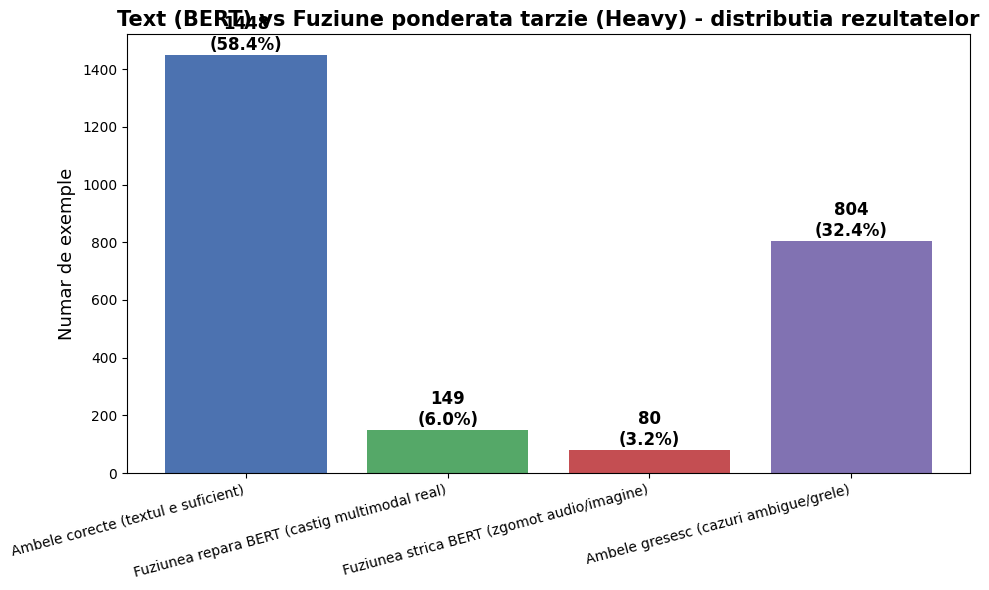


Exemple unde fuziunea REPARA BERT (n=149):


,dialogue_id,utterance_id,utterance,true_label,bert_pred,late_weighted_heavy_pred
0,1,3,"Push 'em out, push 'em out, way out!",happiness,anger,happiness
1,4,1,What?,neutral,surprise,neutral
2,4,8,"Theyre just ten blocks away, if I run, I can ...",neutral,fear,neutral
3,6,1,I dont know exactly. Its-its sorta like wre...,neutral,happiness,neutral
4,8,6,Well there really wasn't much time to get used...,happiness,neutral,happiness
5,9,9,"Oh, its bad. Its really bad. The only thing ...",sadness,disgust,sadness
6,10,2,I dont know if youd understand.,neutral,fear,neutral
7,12,2,"Well, apparently not, and I cant just stand b...",sadness,anger,sadness
8,16,6,Could the waiters gather around to hear tonigh...,neutral,happiness,neutral
9,17,6,What a wank!,anger,sadness,anger



Exemple unde fuziunea STRICA BERT (n=80):


,dialogue_id,utterance_id,utterance,true_label,bert_pred,late_weighted_heavy_pred
0,8,3,Bumpy?,surprise,surprise,neutral
1,11,1,I mean theres no way Joeys gonna make it in ...,fear,fear,happiness
2,12,18,Yes.,neutral,neutral,happiness
3,17,3,Ewww! Oh! Its the Mattress King!,disgust,disgust,happiness
4,17,16,"Im, Im freaking out!",fear,fear,anger
5,22,0,Hey!,happiness,happiness,neutral
6,30,4,Ross's what?,surprise,surprise,neutral
7,32,5,"Oh no, I-Im sorry, I guess we lost track of e...",sadness,sadness,neutral
8,33,1,Go back in time and listen to Phoebe!,anger,anger,neutral
9,39,11,Great. Hes doing great. Dont you worry about...,neutral,neutral,happiness



Salvat -> e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\results\gain_regression_analysis.xlsx


In [156]:
# --------------------------------------------------------------------------------
# 15 - Analiza castig/regresie multimodala (BERT vs Late-Weighted Heavy Fusion)
#
# Intrebare: "Cand adaug audio + imagine peste text, ce castig si ce stric?"
#
# Pentru fiecare exemplu de test se compara:
#   text_correct   = bert_pred                == true_label
#   fusion_correct = late_weighted_heavy_pred == true_label
#
# si se imparte tot setul de test in 4 categorii:
#   1. Text corect, fuziune corecta  -> "Ambele corecte"        (cazuri clare)
#   2. Text gresit, fuziune corecta  -> "Fuziunea repara BERT"  (castig multimodal real)
#   3. Text corect, fuziune gresita  -> "Fuziunea strica BERT"  (zgomot audio/imagine)
#   4. Text gresit, fuziune gresita  -> "Ambele gresesc"        (cazuri ambigue/grele)
#
# Salveaza o defalcare per categorie + exemple in
# results/gain_regression_analysis.xlsx si un grafic de bare cu sumarul.
# --------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'results_df' not in globals():
    results_df = pd.read_excel('../results/full_test_predictions.xlsx')

OUT_DIR = '../results'
os.makedirs(OUT_DIR, exist_ok=True)

# Doar exemplele pentru care fuziunea ponderata heavy are o predictie
# (adica exista un crop de fata detectat)
df = results_df.dropna(subset=['late_weighted_heavy_pred', 'bert_pred']).copy()

df['text_correct']   = df['bert_pred'] == df['true_label']
df['fusion_correct'] = df['late_weighted_heavy_pred'] == df['true_label']

CATEGORY_LABELS = {
    (True,  True):  'Ambele corecte (textul e suficient)',
    (False, True):  'Fuziunea repara BERT (castig multimodal real)',
    (True,  False): 'Fuziunea strica BERT (zgomot audio/imagine)',
    (False, False): 'Ambele gresesc (cazuri ambigue/grele)',
}
CATEGORY_ORDER = [
    'Ambele corecte (textul e suficient)',
    'Fuziunea repara BERT (castig multimodal real)',
    'Fuziunea strica BERT (zgomot audio/imagine)',
    'Ambele gresesc (cazuri ambigue/grele)',
]

df['category'] = df.apply(
    lambda r: CATEGORY_LABELS[(r['text_correct'], r['fusion_correct'])], axis=1
)

# -- Tabel sumar --
n_total = len(df)
summary = (
    df['category'].value_counts()
    .reindex(CATEGORY_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)
summary.columns = ['categorie', 'numar']
summary['procent'] = (summary['numar'] / n_total * 100).round(2)

print(f'Total exemple evaluate: {n_total}')
print(f'Acuratete BERT (doar text)          : {df["text_correct"].mean():.4f}')
print(f'Acuratete fuziune ponderata (heavy) : {df["fusion_correct"].mean():.4f}')
print()
display(summary)

n_repair = summary.loc[summary.categorie == CATEGORY_ORDER[1], 'numar'].iloc[0]
n_break  = summary.loc[summary.categorie == CATEGORY_ORDER[2], 'numar'].iloc[0]
print(f'\nCastig net (reparate - stricate): {n_repair - n_break} exemple '
      f'({(n_repair - n_break) / n_total * 100:.2f}% din setul de test)')
print(f'Raport reparate/stricate: {n_repair / max(n_break, 1):.2f}x')

# -- Defalcare pe clase (ce emotii sunt reparate/stricate de fuziune?) --
class_breakdown = (
    pd.crosstab(df['true_label'], df['category'])
    .reindex(columns=CATEGORY_ORDER, fill_value=0)
)
print('\nDefalcare pe clase (numar exemple):')
display(class_breakdown)

# -- Grafic de bare --
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(summary['categorie'], summary['numar'], color=colors)
for bar, pct in zip(bars, summary['procent']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{int(bar.get_height())}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Numar de exemple', fontsize=13)
ax.set_title('Text (BERT) vs Fuziune ponderata tarzie (Heavy) - distributia rezultatelor',
              fontsize=15, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
fig.tight_layout()
fig_path = os.path.join(OUT_DIR, 'gain_regression_breakdown.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'\nSalvat grafic -> {os.path.abspath(fig_path)}')
plt.show()

# -- Exemple pentru cele doua categorii relevante --
cols = ['dialogue_id', 'utterance_id', 'utterance', 'true_label', 'bert_pred', 'late_weighted_heavy_pred']

repairs = df[df['category'] == CATEGORY_ORDER[1]][cols].reset_index(drop=True)
breaks  = df[df['category'] == CATEGORY_ORDER[2]][cols].reset_index(drop=True)

print(f'\nExemple unde fuziunea REPARA BERT (n={len(repairs)}):')
display(repairs.head(30))

print(f'\nExemple unde fuziunea STRICA BERT (n={len(breaks)}):')
display(breaks.head(30))

# -- Salvare in Excel (un sheet per categorie + sumar) --
out_path = os.path.join(OUT_DIR, 'gain_regression_analysis.xlsx')
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='sumar', index=False)
    class_breakdown.to_excel(writer, sheet_name='defalcare_pe_clase')
    for cat in CATEGORY_ORDER:
        sheet = cat.split(' (')[0][:31]  # limita Excel pentru numele sheet-ului
        df[df['category'] == cat][cols].to_excel(writer, sheet_name=sheet, index=False)

print(f'\nSalvat -> {os.path.abspath(out_path)}')


---
## 16 - Analiza completa pentru un singur utterance

Functia `analyze_utterance(dialogue_id, utterance_id)` calculeaza predictiile tuturor celor 6 modele unimodale (heavy: BERT, wav2vec2, ViT-B/16 | light: DistilBERT, DistilHuBERT, MobileNetV3-Small) si ale celor 6 variante de fuziune (late-weighted, MLP intermediar, gated - heavy/light), apoi ruleaza toate variantele de explicabilitate (Occlusion + Integrated Gradients pentru BERT/DistilBERT, EigenCAM + Attention Rollout pentru ViT, EigenCAM pentru MobileNet). Tot rezultatul (tabel predictii CSV + figuri XAI) se salveaza in `results/utterance_{utterance_id}/`.

=== Utterance d=34 u=15 ===
"There shouldnt be all this rules and restrictions!"



e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 900.40it/s, Materializing param=classifier.weight]                                      


[XAI] Model text incarcat (heavy): bert_base_uncased


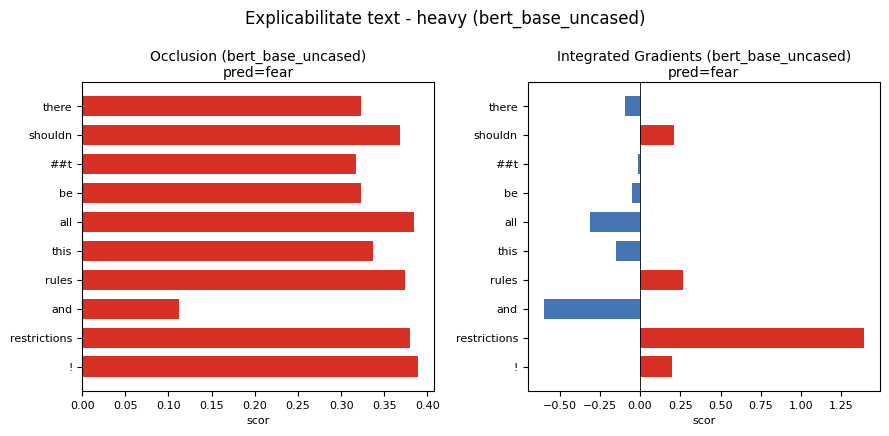

Salvat -> ../results/utterance_15\text_xai_heavy.png
[XAI] Model fata incarcat (heavy): vit_b_16  (is_vit=True)


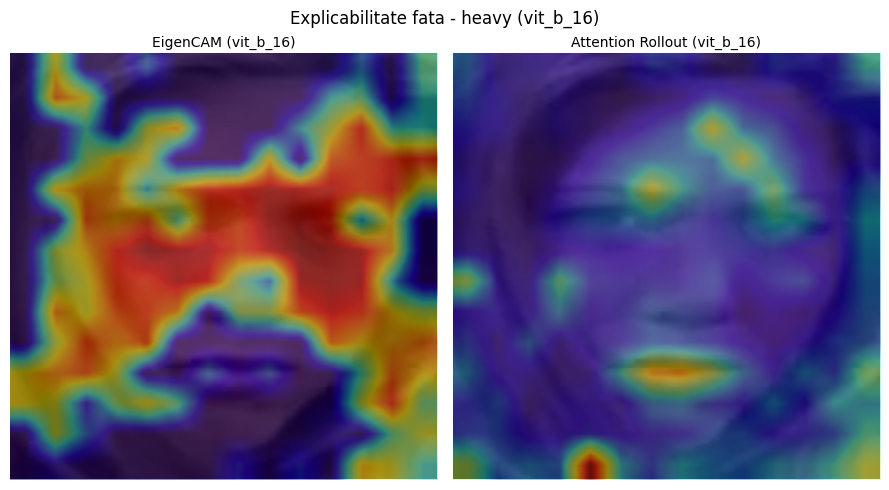

Salvat -> ../results/utterance_15\face_xai_heavy.png


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 993.27it/s, Materializing param=pre_classifier.weight]                                   


[XAI] Model text incarcat (light): distilbert_base_uncased


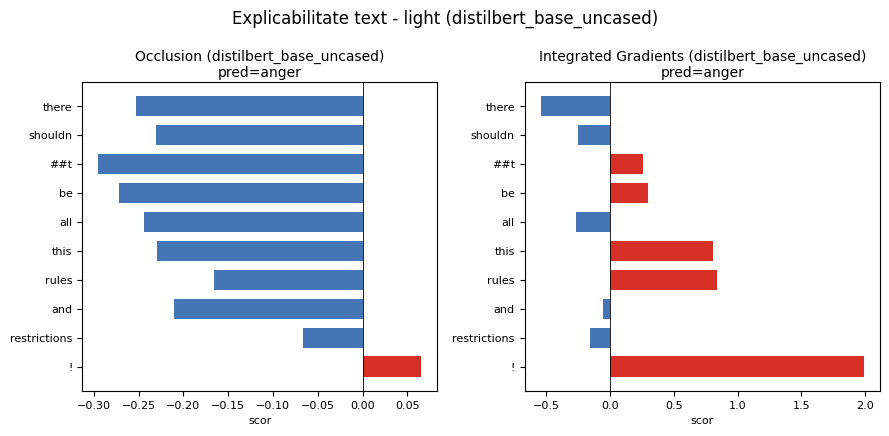

Salvat -> ../results/utterance_15\text_xai_light.png
[XAI] Model fata incarcat (light): mobilenet_v3_small  (is_vit=False)


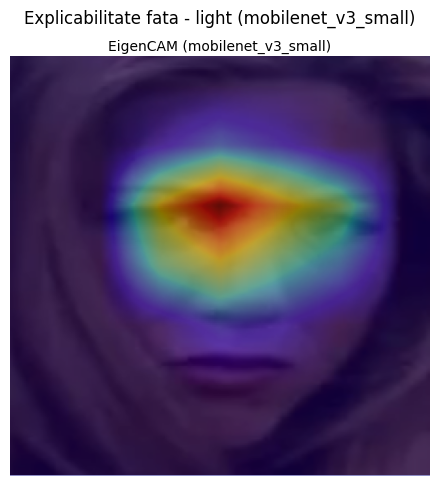

Salvat -> ../results/utterance_15\face_xai_light.png

Salvat tabel predictii -> ../results/utterance_15\predictions.csv


,valoare
dialogue_id,34
utterance_id,15
utterance,There shouldnt be all this rules and restrict...
true_label,anger
bert_pred,fear
bert_pred_conf,0.4397
wav2vec2_pred,happiness
wav2vec2_pred_conf,0.6591
vit_pred,anger
vit_pred_conf,0.4765


: 

In [ ]:
# --------------------------------------------------------------------------------
# 16 - Analiza completa pentru un singur utterance
#
# Functia analyze_utterance(dialogue_id, utterance_id) calculeaza:
#   - predictiile celor 6 modele unimodale (heavy: BERT, wav2vec2, ViT-B/16 |
#     light: DistilBERT, DistilHuBERT, MobileNetV3-Small)
#   - predictiile celor 6 variante de fuziune (late-weighted, intermediate MLP,
#     gated - heavy si light)
#   - explicabilitate text (Occlusion + Integrated Gradients) pentru BERT si
#     DistilBERT, atribuita catre clasa prezisa de fiecare model
#   - explicabilitate fata (EigenCAM + Attention Rollout) pentru ViT si
#     EigenCAM pentru MobileNet (rollout disponibil doar pentru ViT)
#
# Toate rezultatele (tabel predictii + figuri XAI) sunt salvate in
# results/utterance_{utterance_id}/
# --------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.models.face_model import load_face_model
from src.explainability.text_explainability import TextExplainer
from src.explainability.face_explainability import FaceExplainer
from src.evaluation.intermediate_fusion import ProjectionFusionMLP
from src.evaluation.gated_fusion import GatedFusionLight, GatedFusionHeavy
from safetensors import safe_open

EMOTIONS = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
ID2EMO   = {i: e for i, e in enumerate(EMOTIONS)}
TEST_CSV = '../Data/MELD.Raw/test_sent_emo.csv'
_GATED_B = '../experiments/fusion/gated'
_FACE_META_CSV = '../Data/processed_meld_faces/v1/test/metadata.csv'
_FACE_IMG_ROOT = '../Data/processed_meld_faces/v1/test/images'
SKIP_TOKS = {'[CLS]', '[SEP]', '[PAD]', '<s>', '</s>', '<pad>'}

if 'DEVICE' not in globals():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -- Text utterance lookup --
_test_csv_df = pd.read_csv(TEST_CSV)
_utt_map = {(int(r.Dialogue_ID), int(r.Utterance_ID)): str(r.Utterance) for r in _test_csv_df.itertuples()}

# -- Face metadata + transform --
_face_meta = pd.read_csv(_FACE_META_CSV)
_face_meta = _face_meta[_face_meta['status'] == 'ok'].copy()
_face_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def _get_face_image(d_id, u_id):
    """Returneaza (pil_img, tensor[1,3,224,224]) pentru cel mai bun crop, sau (None, None)."""
    rows = _face_meta[
        (_face_meta['dialogue_id'] == d_id) & (_face_meta['utterance_id'] == u_id)
    ].sort_values('selection_rank')
    if rows.empty:
        return None, None
    img_rel = rows.iloc[0]['image_path'].replace('\\', '/')
    img_name = os.path.basename(img_rel)
    img_path = os.path.join(_FACE_IMG_ROOT, img_name)
    if not os.path.exists(img_path):
        return None, None
    pil = Image.open(img_path).convert('RGB')
    return pil, _face_tf(pil).unsqueeze(0)


def _npz(cache_root, name):
    d = np.load(os.path.join(cache_root, f'{name}_test.npz'))
    return d['embeddings'], d['labels'].astype(int), d['d_ids'].astype(int), d['u_ids'].astype(int)


def _hf_head(run_dir_rel, weight_key='classifier.weight', bias_key='classifier.bias'):
    sf = os.path.join(run_dir_rel, 'model', 'model.safetensors')
    with safe_open(sf, framework='pt', device='cpu') as f:
        return f.get_tensor(weight_key), f.get_tensor(bias_key)


def _pt_head(ckpt_path, weight_key, bias_key):
    sd = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    return sd[weight_key], sd[bias_key]


def _logits(embs, W, b):
    return torch.tensor(embs, dtype=torch.float32) @ W.T + b


def _find_idx(dids, uids, d_id, u_id):
    matches = np.where((dids == d_id) & (uids == u_id))[0]
    return int(matches[0]) if len(matches) else None


# -- Cache de configuratii / modele complete (incarcate o singura data) --
_BACKBONE_CFG = {}


def _cfg(backbone):
    if backbone not in _BACKBONE_CFG:
        _BACKBONE_CFG[backbone] = load_json(os.path.join(INTER_FUSION_ROOT, backbone, 'config.json'))
    return _BACKBONE_CFG[backbone]


_FULL_TEXT = {}


def _full_text(backbone):
    if backbone not in _FULL_TEXT:
        cfg = _cfg(backbone)
        slug = os.path.basename(cfg['text_run_dir'].replace('\\', '/'))
        model_dir = os.path.join(EXP_ROOT, VERSION, slug, 'model')
        model = AutoModelForSequenceClassification.from_pretrained(model_dir)
        tok = AutoTokenizer.from_pretrained(model_dir)
        _FULL_TEXT[backbone] = (slug, TextExplainer(model, tok, DEVICE))
        print(f'[XAI] Model text incarcat ({backbone}): {slug}')
    return _FULL_TEXT[backbone]


_FULL_FACE = {}


def _full_face(backbone):
    if backbone not in _FULL_FACE:
        cfg = _cfg(backbone)
        slug = os.path.basename(cfg['face_run_dir'].replace('\\', '/'))
        ckpt = os.path.join(EXP_ROOT_FACE, VERSION, slug, 'model', 'best_model.pt')
        model = load_face_model(slug, num_classes=7, device=DEVICE)
        sd = torch.load(ckpt, map_location='cpu')
        model.load_state_dict(sd)
        model = model.to(DEVICE).eval()
        is_vit = 'vit' in slug
        _FULL_FACE[backbone] = (slug, FaceExplainer(model, slug, DEVICE), is_vit)
        print(f'[XAI] Model fata incarcat ({backbone}): {slug}  (is_vit={is_vit})')
    return _FULL_FACE[backbone]


def _plot_text_bars(ax, tokens, scores, title):
    keep = [(t, s) for t, s in zip(tokens, scores) if t not in SKIP_TOKS]
    if not keep:
        ax.set_title(title, fontsize=9)
        ax.text(0.5, 0.5, '(fara tokeni de continut)', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        return
    toks, vals = zip(*keep)
    colors = ['#d73027' if v > 0 else '#4575b4' for v in vals]
    ax.barh(range(len(toks)), vals, color=colors, edgecolor='none', height=0.7)
    ax.set_yticks(range(len(toks)))
    ax.set_yticklabels(toks, fontsize=8)
    ax.axvline(0, color='k', linewidth=0.6)
    ax.set_xlabel('scor', fontsize=8)
    ax.set_title(title, fontsize=10, pad=4)
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=8)


def _plot_saliency(ax, pil_img, sal, title):
    lo, hi = sal.min(), sal.max()
    sal_n = (sal - lo) / (hi - lo + 1e-8)
    arr = np.array(pil_img.resize((224, 224)))
    ax.imshow(arr)
    ax.imshow(sal_n, cmap='jet', alpha=0.45, vmin=0, vmax=1,
              extent=[0, 224, 224, 0], interpolation='bilinear')
    ax.set_title(title, fontsize=10, pad=4)
    ax.axis('off')


def analyze_utterance(dialogue_id, utterance_id):
    """
    Genereaza predictiile tuturor modelelor (unimodale + fuziuni) si toate
    variantele de explicabilitate (text + fata) pentru utterance-ul
    (dialogue_id, utterance_id) si salveaza totul in
    results/utterance_{utterance_id}/.
    """
    out_dir = f'../results/utterance_{utterance_id}'
    os.makedirs(out_dir, exist_ok=True)

    key = (int(dialogue_id), int(utterance_id))
    utt_text = _utt_map.get(key, '[utterance negasit in CSV]')
    print(f'=== Utterance d={dialogue_id} u={utterance_id} ===')
    print(f'"{utt_text}"\n')

    pred_row = {'dialogue_id': dialogue_id, 'utterance_id': utterance_id, 'utterance': utt_text}

    for backbone in ['heavy', 'light']:
        cache_root = os.path.join(INTER_FUSION_ROOT, backbone, 'cache')
        cfg = _cfg(backbone)
        emb_dims = cfg['emb_dims']

        te, tl, td, tu = _npz(cache_root, 'text')
        ae, al, ad, au = _npz(cache_root, 'audio')
        fe, fl, fd, fu = _npz(cache_root, 'face')

        ti = _find_idx(td, tu, *key)
        ai = _find_idx(ad, au, *key)
        fi = _find_idx(fd, fu, *key)

        if ti is None or ai is None:
            print(f'[{backbone}] lipsesc embeddings text/audio pentru acest utterance - sarit')
            continue

        if 'true_label' not in pred_row:
            pred_row['true_label'] = ID2EMO[int(tl[ti])]

        txt_e = te[ti:ti + 1]
        aud_e = ae[ai:ai + 1]

        # -- Heads unimodale --
        txt_slug = os.path.basename(cfg['text_run_dir'].replace('\\', '/'))
        W_t, b_t = _hf_head(os.path.join(EXP_ROOT, VERSION, txt_slug))
        txt_logits = _logits(txt_e, W_t, b_t)

        aud_slug = os.path.basename(cfg['audio_run_dir'].replace('\\', '/'))
        W_a, b_a = _hf_head(os.path.join(EXP_ROOT_AUDIO, VERSION, aud_slug))
        aud_logits = _logits(aud_e, W_a, b_a)

        text_col = 'bert_pred' if backbone == 'heavy' else 'distilbert_pred'
        audio_col = 'wav2vec2_pred' if backbone == 'heavy' else 'distilhubert_pred'
        face_col = 'vit_pred' if backbone == 'heavy' else 'mobilenet_pred'

        txt_probs = torch.softmax(txt_logits, dim=-1)[0]
        aud_probs = torch.softmax(aud_logits, dim=-1)[0]
        txt_pred = int(txt_probs.argmax())
        aud_pred = int(aud_probs.argmax())

        pred_row[text_col] = ID2EMO[txt_pred]
        pred_row[f'{text_col}_conf'] = round(float(txt_probs[txt_pred]), 4)
        pred_row[audio_col] = ID2EMO[aud_pred]
        pred_row[f'{audio_col}_conf'] = round(float(aud_probs[aud_pred]), 4)

        # -- Head fata + fuziuni (doar daca exista crop de fata in cache) --
        fac_slug = os.path.basename(cfg['face_run_dir'].replace('\\', '/'))
        fac_ckpt = os.path.join(EXP_ROOT_FACE, VERSION, fac_slug, 'model', 'best_model.pt')
        if 'vit' in fac_slug:
            W_f, b_f = _pt_head(fac_ckpt, 'heads.head.1.weight', 'heads.head.1.bias')
        else:
            W_f, b_f = _pt_head(fac_ckpt, 'classifier.3.weight', 'classifier.3.bias')

        has_face = fi is not None
        if has_face:
            fac_e = fe[fi:fi + 1]
            fac_logits = _logits(fac_e, W_f, b_f)
            fac_probs = torch.softmax(fac_logits, dim=-1)[0]
            fac_pred = int(fac_probs.argmax())
            pred_row[face_col] = ID2EMO[fac_pred]
            pred_row[f'{face_col}_conf'] = round(float(fac_probs[fac_pred]), 4)

            feats_t = {
                'text':  torch.tensor(txt_e, dtype=torch.float32),
                'audio': torch.tensor(aud_e, dtype=torch.float32),
                'face':  torch.tensor(fac_e, dtype=torch.float32),
            }

            # late weighted
            w = load_json(os.path.join(LATE_FUSION_ROOT, backbone, 'weights.json'))
            late_logits = w['text'] * txt_logits + w['audio'] * aud_logits + w['face'] * fac_logits
            late_probs = torch.softmax(late_logits, dim=-1)[0]
            late_pred = int(late_probs.argmax())
            late_col = f'late_weighted_{backbone}_pred'
            pred_row[late_col] = ID2EMO[late_pred]
            pred_row[f'{late_col}_conf'] = round(float(late_probs[late_pred]), 4)

            # intermediate (ProjectionFusionMLP)
            mlp = ProjectionFusionMLP(
                in_dims=emb_dims,
                d_proj=cfg.get('mlp_d_proj', 128),
                d_hidden=cfg.get('mlp_d_hidden', 256),
                num_classes=7, dropout=0.0, modality_dropout=0.0,
            )
            mlp.load_state_dict(torch.load(
                os.path.join(INTER_FUSION_ROOT, backbone, 'fusion_mlp.pt'),
                map_location='cpu', weights_only=True))
            mlp.eval()
            with torch.no_grad():
                mlp_logits = mlp(feats_t)
            mlp_probs = torch.softmax(mlp_logits, dim=-1)[0]
            mlp_pred = int(mlp_probs.argmax())
            mlp_col = f'mlp_{backbone}_pred'
            pred_row[mlp_col] = ID2EMO[mlp_pred]
            pred_row[f'{mlp_col}_conf'] = round(float(mlp_probs[mlp_pred]), 4)

            # gated fusion - doar combinatiile cerute
            if backbone == 'light':
                cfg_g = load_json(os.path.join(_GATED_B, 'light', VERSION, 'light', 'config.json'))
                ckpt_g = os.path.join(_GATED_B, 'light', VERSION, 'light', 'gated_fusion.pt')
                model_g = GatedFusionLight(
                    in_dims=emb_dims, d_proj=cfg_g.get('d_proj', 128),
                    d_hidden=cfg_g.get('d_hidden', 128), num_classes=7, dropout=0.0,
                )
                gated_col = 'gated_light_light_pred'
            else:
                cfg_g = load_json(os.path.join(_GATED_B, 'heavy', VERSION, 'heavy', 'config.json'))
                ckpt_g = os.path.join(_GATED_B, 'heavy', VERSION, 'heavy', 'gated_fusion.pt')
                model_g = GatedFusionHeavy(
                    in_dims=emb_dims, d_model=cfg_g.get('d_model', 256),
                    nhead=cfg_g.get('nhead', 4), num_layers=cfg_g.get('num_layers', 2),
                    d_ff=cfg_g.get('d_ff', 512), d_hidden=cfg_g.get('d_hidden', 256),
                    num_classes=7, dropout=0.0,
                )
                gated_col = 'gated_heavy_heavy_pred'
            model_g.load_state_dict(torch.load(ckpt_g, map_location='cpu', weights_only=True))
            model_g.eval()
            with torch.no_grad():
                gated_logits = model_g(feats_t)
            gated_probs = torch.softmax(gated_logits, dim=-1)[0]
            gated_pred = int(gated_probs.argmax())
            pred_row[gated_col] = ID2EMO[gated_pred]
            pred_row[f'{gated_col}_conf'] = round(float(gated_probs[gated_pred]), 4)
        else:
            print(f'[{backbone}] nu exista crop de fata -> coloanele dependente de fata raman necompletate')

        # -- Explicabilitate text (Occlusion + Integrated Gradients) --
        slug_t, txt_explainer = _full_text(backbone)
        fig, axes = plt.subplots(1, 2, figsize=(9, max(4, len(utt_text.split()) * 0.3 + 2)))
        toks_o, scores_o, _ = txt_explainer.token_occlusion(utt_text, target_class=txt_pred)
        _plot_text_bars(axes[0], toks_o, scores_o, f'Occlusion ({slug_t})\npred={ID2EMO[txt_pred]}')
        toks_ig, scores_ig, _ = txt_explainer.integrated_gradients(utt_text, target_class=txt_pred)
        _plot_text_bars(axes[1], toks_ig, scores_ig, f'Integrated Gradients ({slug_t})\npred={ID2EMO[txt_pred]}')
        fig.suptitle(f'Explicabilitate text - {backbone} ({slug_t})', fontsize=12)
        fig.tight_layout()
        fpath = os.path.join(out_dir, f'text_xai_{backbone}.png')
        fig.savefig(fpath, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'Salvat -> {fpath}')

        # -- Explicabilitate fata (EigenCAM + Attention Rollout pentru ViT) --
        if has_face:
            pil_img, face_tensor = _get_face_image(*key)
            if pil_img is not None:
                slug_f, fac_explainer, is_vit = _full_face(backbone)
                methods = ['gradcam'] + (['attention_rollout'] if is_vit else [])
                fig, axes = plt.subplots(1, len(methods), figsize=(4.5 * len(methods), 5))
                if len(methods) == 1:
                    axes = [axes]
                for ax, m in zip(axes, methods):
                    if m == 'gradcam':
                        sal, _ = fac_explainer.grad_cam(face_tensor)
                        _plot_saliency(ax, pil_img, sal, f'EigenCAM ({slug_f})')
                    else:
                        sal = fac_explainer.attention_rollout(face_tensor)
                        _plot_saliency(ax, pil_img, sal, f'Attention Rollout ({slug_f})')
                fig.suptitle(f'Explicabilitate fata - {backbone} ({slug_f})', fontsize=12)
                fig.tight_layout()
                fpath = os.path.join(out_dir, f'face_xai_{backbone}.png')
                fig.savefig(fpath, dpi=120, bbox_inches='tight')
                plt.show()
                plt.close(fig)
                print(f'Salvat -> {fpath}')
            else:
                print(f'[{backbone}] imaginea cu fata nu a fost gasita pe disc -> XAI fata sarit')

    # -- Salvare tabel predictii --
    pred_df = pd.DataFrame([pred_row])
    csv_path = os.path.join(out_dir, 'predictions.csv')
    pred_df.to_csv(csv_path, index=False)
    print(f'\nSalvat tabel predictii -> {csv_path}')
    display(pred_df.T.rename(columns={0: 'valoare'}))
    return pred_df


# -- Exemplu de utilizare --
# Modifica (dialogue_id, utterance_id) cu exemplul dorit din setul de test.
pred_df = analyze_utterance(dialogue_id=34, utterance_id=15)
